<a href="https://colab.research.google.com/github/Kintsukuro1/Mineria-Datos/blob/Prueba-3/Examen_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/Kintsukuro1/Mineria-Datos/blob/main/proyecto_mineria_felipe_ruiz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Proyecto - Evaluación de Minería de Datos

## Información del Grupo

- **Nombre o Número de Grupo:** Grupo 1
- **Sección:** BIY7121-004D
- **Fecha de Entrega:** [Indicar la fecha de entrega del informe]

---

## Integrantes del Grupo

### Estudiante 1
- **Nombre:** Felipe
- **Apellido:** Ruiz
- **Correo institucional:** fe.ruizm@duocuc.cl

---

## Tema del Proyecto
Análisis y predicción del comportamiento de juegos de casino online a partir de variables como RTP, volatilidad, multiplicadores y características de los juegos.

---

## Descripción del Proyecto
Este proyecto analiza un dataset de juegos de casino online con el fin de responder cuatro objetivos analíticos diferenciados, cada uno abordado con un modelo distinto:

1. **¿Qué variables técnicas de un juego predicen mejor su ganancia máxima posible?** → Regresión Múltiple
2. **¿Qué combinación de características define si un juego es de alto potencial para el usuario?** → Árbol de Decisión
3. **¿Qué atributos de los juegos tienden a aparecer juntos en los catálogos de casino?** → Market Basket Analysis
4. **¿Existen grupos naturales de juegos según sus características numéricas?** → K-Means

El modelo resultante puede ser utilizado por operadores de casinos para personalizar su oferta, optimizar el catálogo y mejorar la retención de usuarios.


---

## Introducción a la Metodología

Este proyecto sigue la metodología **CRISP-DM** (*Cross Industry Standard Process for Data Mining*), compuesta por seis fases iterativas que guían el análisis desde la comprensión del negocio hasta la evaluación del modelo. La elección de CRISP-DM se justifica porque:

- Es el estándar más utilizado en proyectos de minería de datos de la industria.
- Permite iterar entre fases según los hallazgos intermedios.
- Estructura claramente los entregables esperados en cada etapa.

**Diagrama de fases aplicadas:**

| Fase CRISP-DM | Descripción | Sección |
|---|---|---|
| 1. Comprensión del negocio | Definición de objetivos y preguntas analíticas | §1 |
| 2. Comprensión de los datos | Inspección estructural, tipos y calidad | §2 |
| 3. Preparación de los datos | Limpieza, encoding y escalado | §3 |
| 4. Modelado | Aplicación de 3 técnicas de minería | §5 |
| 5. Evaluación | Métricas por tipo de modelo | §6 |
| 6. Despliegue | Propuesta de integración en producción | §7 |


<div style="background:linear-gradient(90deg,#1a1a2e,#16213e);padding:20px 28px;border-radius:10px;border-left:6px solid #e94560;margin:16px 0">
<span style="color:#e94560;font-size:13px;font-weight:700;letter-spacing:2px;text-transform:uppercase">MÓDULO 1</span><br>
<span style="color:#fff;font-size:22px;font-weight:700">🎯 Comprensión del Negocio</span><br>
<span style="color:#a8a8b3;font-size:13px">Definición de objetivos analíticos, preguntas de negocio y criterios de éxito.</span>
</div>


---

## 1. Comprensión del Negocio

El sector de casinos online es altamente competitivo. Las plataformas deben optimizar continuamente su catálogo de juegos para maximizar tanto la satisfacción del usuario como la rentabilidad del negocio. Este proyecto busca extraer conocimiento útil desde los datos técnicos y comerciales de los juegos disponibles.

### Contexto del problema
Un operador de casino online debe tomar decisiones sobre:
- **Qué juegos adquirir** de los proveedores disponibles.
- **Cómo destacar juegos** en la interfaz para maximizar la retención.
- **Qué combinaciones de características** son más comunes en el mercado.

El dataset disponible contiene información técnica y comercial de juegos, lo que permite responder estas preguntas sin necesidad de datos de comportamiento de usuarios (que serían más difíciles de obtener).

### Objetivos analíticos

**Objetivo 1 — Regresión Múltiple**
> *¿Qué variables técnicas de un juego (volatilidad, jackpot, free spins, RTP, multiplicador, etc.) predicen mejor la ganancia máxima posible (`max_win`)?*
>
> Permite a los operadores estimar el potencial de pago de un juego antes de adquirirlo, basándose solo en su ficha técnica.

**Objetivo 2 — Árbol de Decisión**
> *¿Qué combinación de características (free spins, bonus buy, jackpot, volatilidad, tipo de juego) define si un juego tendrá una ganancia máxima alta?*
>
> Permite clasificar automáticamente juegos nuevos al momento de incorporarlos al catálogo, priorizando los de mayor atractivo.

**Objetivo 3 — Market Basket Analysis**
> *¿Qué combinaciones de atributos (tipo de juego, free spins, bonus buy, jackpot, volatilidad) tienden a aparecer juntas en los juegos del catálogo?*
>
> Permite descubrir patrones de diseño frecuentes en la industria y anticipar qué características suelen venir "empaquetadas" juntas.

**Objetivo 4 — K-Means**
> *¿Existen grupos naturales de juegos según sus atributos numéricos (RTP, apuesta mínima, ganancia máxima, multiplicador) que permitan segmentar el catálogo?*
>
> Permite descubrir perfiles de juego no definidos a priori, útiles para personalización y estrategias de marketing diferenciadas.

### Criterio de éxito del proyecto
- Regresión Múltiple: R² ≥ 0.5 (modelo explica más de la mitad de la varianza)
- Árbol de Decisión: F1-Score ≥ 0.70 (clasificación balanceada)
- MBA: Al menos 5 reglas con lift > 1.5 y confianza > 0.6
- K-Means: Silhouette Score > 0.3 (clusters razonablemente bien separados)

### ¿Para quién sirve este análisis?
- Equipos de producto y catálogo de casinos online
- Departamentos de marketing para segmentación de usuarios
- Proveedores de juegos que buscan posicionar su oferta


In [1]:
# Imports e ignoraciones de warning

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gc # For garbage collection in MBA section

# Scikit-learn imports
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error,
    accuracy_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    silhouette_score,
    silhouette_samples
)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.cluster import KMeans
from sklearn.utils import resample # For sampling in K-Means and MBA sections

# mlxtend for Market Basket Analysis
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', message='datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).')


<div style="background:linear-gradient(90deg,#1a1a2e,#16213e);padding:20px 28px;border-radius:10px;border-left:6px solid #e94560;margin:16px 0">
<span style="color:#e94560;font-size:13px;font-weight:700;letter-spacing:2px;text-transform:uppercase">MÓDULO 2</span><br>
<span style="color:#fff;font-size:22px;font-weight:700">🔍 Comprensión de los Datos</span><br>
<span style="color:#a8a8b3;font-size:13px">Inspección estructural del dataset: tipos de variables, distribuciones y calidad.</span>
</div>


---

## 2. Comprensión de los Datos

- **Fuente del dataset:** `online_casino_games_dataset_v2.csv`
- **Variables objetivo según modelo:**
  - Regresión Múltiple: `max_win` (ganancia máxima potencial)
  - Árbol de Decisión: `alto_max_win` (binaria construida desde `max_win` sobre la mediana)
  - Market Basket Analysis: sin variable objetivo; se trabaja con ítems categóricos
- **Variables predictoras:** casino, proveedor, tipo de juego, volatilidad, jackpot, apuesta mínima, RTP, multiplicador máximo, compatibilidad móvil, free spins, compra de bonus, año de lanzamiento, jurisdicción, moneda.
- **Tipos de datos:** numéricos continuos, categóricos nominales/ordinales, booleanos, temporales.


In [2]:
# Cargar dataset
df = pd.read_csv('/content/online_casino_games_dataset_v2.csv')

print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")
df.head()


Filas: 1200000 | Columnas: 20


,casino,game,provider,rtp,volatility,jackpot,country_availability,min_bet,max_win,game_type,game_category,license_jurisdiction,release_year,currency,mobile_compatible,free_spins_feature,bonus_buy_available,max_multiplier,languages,last_updated
0,Guts Casino,Texas Hold'em Bonus,Saucify,98.83,Medium,NaN,AR|BR|CH|CO|CY|DE|EE|ES|IE|IL|KE|MT|NZ|PE|PT|R...,1.00,435957.16,poker,Video Poker,MGA,2021,SEK|USD,True,False,False,356.0,EN|ES|TR|IT|JA|DE|FR|CS,2024-09-20
1,Expekt,Mines,Playtech,98.05,Low,NaN,BG|HR|ID|LT|NO|PH|SE|TR,0.25,1396.15,crash,Crash,Curaçao,2018,NZD|BRL|CAD|SEK|AUD,True,False,False,206.0,EN|SV|TR|ZH|PT|ES|FR|JA,2024-02-03
2,Betinia,Mega Vault,Gamomat,95.43,Very High,NaN,CH|ES|GB|HU|ID|IE|IN|LT|NO|SE|SG|VN,0.10,1180.12,slot,3D Slot,Isle of Man,2014,NZD|AUD|BRL|GBP|CAD,True,True,False,1787.0,EN|DE|FI|HU|PT|ZH|FR|JA,2024-07-09
3,Pinnacle,Casino Hold'em Pro,4ThePlayer,99.50,Medium,NaN,BE|BR|MY|NG|PL,0.05,236507.50,poker,Three Card Poker,MGA,2023,DKK|NZD|SEK,True,False,False,369.0,EN|ES|SV|DA|CS|FR|ZH|FI|NO|PT|HU|KO,2024-06-27
4,Winnerz,Solar Star Xtreme,Hacksaw Gaming,97.18,High,NaN,CL|KE|PT|SG|SI,0.20,1093.45,slot,Jackpot Slot,MGA,2022,NOK|GBP,True,True,False,1970.0,EN|JA|PT|KO|ES,2024-04-24


In [3]:
# Inspección estructural: tipos de datos y conteo de no-nulos
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200000 entries, 0 to 1199999
Data columns (total 20 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   casino                1200000 non-null  object 
 1   game                  1200000 non-null  object 
 2   provider              1200000 non-null  object 
 3   rtp                   1200000 non-null  float64
 4   volatility            1200000 non-null  object 
 5   jackpot               128457 non-null   object 
 6   country_availability  1200000 non-null  object 
 7   min_bet               1200000 non-null  float64
 8   max_win               1200000 non-null  float64
 9   game_type             1200000 non-null  object 
 10  game_category         1200000 non-null  object 
 11  license_jurisdiction  1200000 non-null  object 
 12  release_year          1200000 non-null  int64  
 13  currency              1200000 non-null  object 
 14  mobile_compatible     1200000 non-

In [4]:
# Nombres de columnas disponibles
print(df.columns.tolist())


['casino', 'game', 'provider', 'rtp', 'volatility', 'jackpot', 'country_availability', 'min_bet', 'max_win', 'game_type', 'game_category', 'license_jurisdiction', 'release_year', 'currency', 'mobile_compatible', 'free_spins_feature', 'bonus_buy_available', 'max_multiplier', 'languages', 'last_updated']


##  Diccionario de Datos

| Columna | Descripción | Tipo | Subtipo |
|---|---|---|---|
| `casino` | Nombre del casino | Categórica | Nominal |
| `game` | Nombre del juego | Categórica | Nominal |
| `provider` | Proveedor del juego | Categórica | Nominal |
| `rtp` | Porcentaje de retorno esperado | Numérica | Continua |
| `volatility` | Nivel de volatilidad | Categórica | Ordinal |
| `jackpot` | Si incluye jackpot | Categórica | Binaria |
| `country_availability` | Países donde está habilitado | Categórica | Nominal |
| `min_bet` | Apuesta mínima | Numérica | Continua |
| `max_win` | Ganancia máxima potencial | Numérica | Continua |
| `game_type` | Tipo general del juego | Categórica | Nominal |
| `game_category` | Categoría específica del juego | Categórica | Nominal |
| `license_jurisdiction` | Jurisdicción regulatoria | Categórica | Nominal |
| `release_year` | Año de lanzamiento | Numérica | Discreta |
| `currency` | Moneda principal | Categórica | Nominal |
| `mobile_compatible` | Compatibilidad con móviles | Categórica | Binaria |
| `free_spins_feature` | Tiene función de free spins | Categórica | Binaria |
| `bonus_buy_available` | Permite comprar bono directamente | Categórica | Binaria |
| `max_multiplier` | Multiplicador máximo de ganancia | Numérica | Discreta |
| `languages` | Idiomas disponibles | Categórica | Nominal |
| `last_updated` | Fecha de última actualización | Temporal | Fecha |

**Interpretación:** El dataset contiene 20 variables que cubren aspectos técnicos, comerciales y regulatorios de los juegos. Las variables numéricas continuas (`rtp`, `min_bet`, `max_win`, `max_multiplier`) son candidatas a escalado. Las categóricas nominales requieren codificación. Las booleanas se tratarán como indicadores 0/1.

> **Nota importante sobre la variable objetivo del Árbol de Decisión:** En esta versión mejorada, se define `alto_max_win` como variable objetivo (max_win sobre la mediana), **excluyendo** `max_win` y `max_multiplier` del set de predictores para evitar data leakage.


<div style="background:linear-gradient(90deg,#1a1a2e,#16213e);padding:20px 28px;border-radius:10px;border-left:6px solid #e94560;margin:16px 0">
<span style="color:#e94560;font-size:13px;font-weight:700;letter-spacing:2px;text-transform:uppercase">MÓDULO 3</span><br>
<span style="color:#fff;font-size:22px;font-weight:700">🧹 Preparación de los Datos</span><br>
<span style="color:#a8a8b3;font-size:13px">Limpieza, imputación, encoding, escalado y separación del holdout independiente.</span>
</div>


---

## 3. Preparación de los Datos

Esta fase incluye:
- Detección y limpieza de valores nulos
- Eliminación de duplicados
- Segmentación por tipo de variable
- Imputación diferenciada
- Encoding de categóricas
- Escalado de numéricas

> **Nota:** Se mantiene una copia del dataset original (`df_raw`) para el Market Basket Analysis, que requiere las variables categóricas sin transformar.


In [5]:
# ── Guardar copia original para Market Basket Analysis ───────────────────────
df_raw = df.copy()

# ── Limpieza previa ──────────────────────────────────────────────────────────
n_antes = len(df)
df = df.drop_duplicates()
print(f"Filas eliminadas por duplicados: {n_antes - len(df)}")

# Eliminar columnas de alta cardinalidad (no aptas para modelos directamente)
cols_alta_cardinalidad = ['game', 'languages', 'country_availability', 'provider', 'last_updated']
df = df.drop(columns=[c for c in cols_alta_cardinalidad if c in df.columns])
print(f"Columnas eliminadas: {cols_alta_cardinalidad}")
print(f"Shape resultante: {df.shape}")


Filas eliminadas por duplicados: 0
Columnas eliminadas: ['game', 'languages', 'country_availability', 'provider', 'last_updated']
Shape resultante: (1200000, 15)


### 3.1 Depuración de Datos


In [6]:
# ── Diagnóstico de nulos ANTES de imputar ────────────────────────────────────
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(2)
resumen_nulos = pd.DataFrame({
    'Nulos': nulos,
    'Porcentaje (%)': nulos_pct
}).query('Nulos > 0').sort_values('Nulos', ascending=False)

print("Columnas con valores nulos:")
print(resumen_nulos if not resumen_nulos.empty else "  → No hay valores nulos")


Columnas con valores nulos:
                  Nulos  Porcentaje (%)
jackpot         1071543           89.30
max_multiplier   213814           17.82


In [7]:
# ── Segmentación por tipo de variable ────────────────────────────────────────
num_cols  = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols  = df.select_dtypes(include=['object']).columns.tolist()
bool_cols = df.select_dtypes(include=['bool']).columns.tolist()

print(f"Numéricas  ({len(num_cols)}):  {num_cols}")
print(f"Categóricas ({len(cat_cols)}): {cat_cols}")
print(f"Booleanas  ({len(bool_cols)}): {bool_cols}")


Numéricas  (5):  ['rtp', 'min_bet', 'max_win', 'release_year', 'max_multiplier']
Categóricas (7): ['casino', 'volatility', 'jackpot', 'game_type', 'game_category', 'license_jurisdiction', 'currency']
Booleanas  (3): ['mobile_compatible', 'free_spins_feature', 'bonus_buy_available']


In [8]:
# ── Imputación diferenciada ───────────────────────────────────────────────────
# Numéricas → mediana (robusta ante outliers)
for col in num_cols:
    mediana = df[col].median()
    n_imputados = df[col].isnull().sum()
    if n_imputados > 0:
        df[col] = df[col].fillna(mediana)
        print(f"  [{col}] {n_imputados} nulos → mediana = {mediana:.4f}")

# Categóricas → moda (categoría más frecuente)
for col in cat_cols:
    moda = df[col].mode(dropna=True)
    n_imputados = df[col].isnull().sum()
    if not moda.empty and n_imputados > 0:
        df[col] = df[col].fillna(moda.iloc[0])
        print(f"  [{col}] {n_imputados} nulos → moda = '{moda.iloc[0]}'")

# Booleanas → False (criterio conservador: sin evidencia positiva)
for col in bool_cols:
    n_imputados = df[col].isnull().sum()
    if n_imputados > 0:
        df[col] = df[col].fillna(False)
        print(f"  [{col}] {n_imputados} nulos → False")

print("\n✓ Imputación completada")


  [max_multiplier] 213814 nulos → mediana = 749.0000
  [jackpot] 1071543 nulos → moda = 'Local'

✓ Imputación completada


In [9]:
# ── Verificación post-imputación ─────────────────────────────────────────────
nulos_restantes = df.isnull().sum().sum()
print(f"Nulos restantes en el dataset: {nulos_restantes}")
assert nulos_restantes == 0, '¡Aún quedan nulos sin imputar!'
print("✓ Dataset libre de valores nulos")


Nulos restantes en el dataset: 0
✓ Dataset libre de valores nulos


**Interpretación de la imputación:**
- **Numéricas → mediana**: reduce el impacto de outliers y preserva la distribución central.
- **Categóricas → moda**: conserva la categoría más representativa del dataset.
- **Booleanas → False**: criterio conservador cuando no existe evidencia positiva del atributo.


### 3.2 Encoding


In [10]:
# ── One-Hot Encoding para categóricas de baja cardinalidad ──────────────────
cat_cols_actuales = df.select_dtypes(include=['object']).columns.tolist()

cat_cols_ohe   = [col for col in cat_cols_actuales if df[col].nunique() < 10]
cat_cols_label = [col for col in cat_cols_actuales if df[col].nunique() >= 10]

print(f"Columnas para OHE ({len(cat_cols_ohe)}):                {cat_cols_ohe}")
print(f"Columnas descartadas/alta cardinalidad ({len(cat_cols_label)}): {cat_cols_label}")

df_encoded = pd.get_dummies(df, columns=cat_cols_ohe, drop_first=True)
df_encoded = df_encoded.drop(columns=cat_cols_label, errors='ignore')

print(f"\nShape tras encoding: {df_encoded.shape}")


Columnas para OHE (4):                ['volatility', 'jackpot', 'game_type', 'license_jurisdiction']
Columnas descartadas/alta cardinalidad (3): ['casino', 'game_category', 'currency']

Shape tras encoding: (1200000, 25)


**Interpretación:** Se aplicó One-Hot Encoding a variables categóricas con menos de 10 categorías para evitar explosión de dimensionalidad. El parámetro `drop_first=True` reduce redundancia entre columnas codificadas.


In [11]:
# ── Escalado de variables numéricas ──────────────────────────────────────────
# IMPORTANTE: NO escalar max_win aquí; se escala solo en el set de predictores
# para conservar max_win legible al construir la variable objetivo del árbol.
num_cols_encoded = df_encoded.select_dtypes(include=['int64', 'float64']).columns.tolist()

scaler = StandardScaler()
df_encoded[num_cols_encoded] = scaler.fit_transform(df_encoded[num_cols_encoded])

print(f"Variables escaladas ({len(num_cols_encoded)}): {num_cols_encoded}")
print("\nEstadísticas post-escalado (deben ser ≈ media=0, std=1):")
print(df_encoded[num_cols_encoded].describe().loc[['mean','std']].round(4))


Variables escaladas (5): ['rtp', 'min_bet', 'max_win', 'release_year', 'max_multiplier']

Estadísticas post-escalado (deben ser ≈ media=0, std=1):
      rtp  min_bet  max_win  release_year  max_multiplier
mean  0.0      0.0     -0.0           0.0             0.0
std   1.0      1.0      1.0           1.0             1.0


In [12]:
# ── Variable objetivo para el Árbol de Decisión (construida ANTES del escalado) ──
# Se usa df (sin escalar) para que el umbral de mediana sea interpretable.
# alto_max_win = 1 si max_win está sobre la mediana del dataset
mediana_max_win = df['max_win'].median()
df_encoded['alto_max_win'] = (df['max_win'] > mediana_max_win).astype(int)

dist = df_encoded['alto_max_win'].value_counts()
print(f"Mediana de max_win usada como umbral: {mediana_max_win:.2f}")
print(f"Distribución de alto_max_win: {dist.to_dict()}")
print(f"Balance: {dist[1]/len(df_encoded)*100:.1f}% clase 1 | {dist[0]/len(df_encoded)*100:.1f}% clase 0")
print("\n✓ Variable objetivo creada sin data leakage (max_win y max_multiplier no son predictoras del árbol)")


Mediana de max_win usada como umbral: 15891.24
Distribución de alto_max_win: {1: 600000, 0: 600000}
Balance: 50.0% clase 1 | 50.0% clase 0

✓ Variable objetivo creada sin data leakage (max_win y max_multiplier no son predictoras del árbol)


In [13]:
# ── Dataset final preparado ──────────────────────────────────────────────────
df_final = df_encoded.copy()

print(f"Shape final: {df_final.shape}")
print(f"Nulos: {df_final.isnull().sum().sum()}")
df_final.head()


Shape final: (1200000, 26)
Nulos: 0


,rtp,min_bet,max_win,release_year,mobile_compatible,free_spins_feature,bonus_buy_available,max_multiplier,volatility_Low,volatility_Medium,...,game_type_scratch,game_type_slot,game_type_table,license_jurisdiction_Curaçao,license_jurisdiction_Gibraltar,license_jurisdiction_Isle of Man,license_jurisdiction_Kahnawake,license_jurisdiction_MGA,license_jurisdiction_UKGC,alto_max_win
0,1.006504,0.647966,0.148262,0.829314,True,False,False,-0.458599,False,True,...,False,False,False,False,False,False,False,True,False,1
1,0.706904,-0.268467,-0.500478,0.111994,True,False,False,-0.472861,True,False,...,False,False,False,True,False,False,False,False,False,0
2,-0.299443,-0.451753,-0.500800,-0.844432,True,True,False,-0.322534,False,False,...,False,True,False,False,False,True,False,False,False,0
3,1.263852,-0.512849,-0.149489,1.307527,True,False,False,-0.457363,False,True,...,False,False,False,False,False,False,False,True,False,1
4,0.372735,-0.329562,-0.500930,1.068420,True,True,False,-0.305133,False,False,...,False,True,False,False,False,False,False,True,False,0


### 3.3 Set de Datos de Prueba Independiente (Holdout)

Además de la división train/test habitual (80/20) que se usará **dentro** de cada modelo para medir su rendimiento durante el entrenamiento, se reserva un **holdout independiente**: una porción de datos que se separa ahora, antes de tocar ningún modelo, y que no participará en ningún entrenamiento ni ajuste de hiperparámetros.

**Diferencia clave:**
- `train_test_split` (usado más adelante en cada modelo) → evalúa el modelo durante su desarrollo.
- **Holdout** (`df_holdout`) → simula la llegada de "juegos nuevos" al sistema. Se usa **una sola vez**, al final, para confirmar que el modelo generaliza a datos que nunca influyeron ni en el entrenamiento ni en la selección del modelo.

Se reserva un 15% del dataset total de forma aleatoria para garantizar representatividad.


In [14]:
# ── Separar holdout ANTES de entrenar cualquier modelo ───────────────────────
# IMPORTANTE: se conservan los índices originales (sin reset_index) para poder
# recuperar, más adelante, los valores no escalados de max_win desde `df`.
df_dev, df_holdout = train_test_split(df_final, test_size=0.15, random_state=42)

# Dataset de desarrollo: el que se usa en todo el modelado (train+test interno)
df_final = df_dev

print(f"Dataset de desarrollo (train+test interno): {df_final.shape[0]} filas")
print(f"Set de prueba independiente (holdout)      : {df_holdout.shape[0]} filas")
print(f"\n✓ El holdout queda apartado y NO se usa hasta la sección 6 (Evaluación Final)")

Dataset de desarrollo (train+test interno): 1020000 filas
Set de prueba independiente (holdout)      : 180000 filas

✓ El holdout queda apartado y NO se usa hasta la sección 6 (Evaluación Final)


<div style="background:linear-gradient(90deg,#1a1a2e,#16213e);padding:20px 28px;border-radius:10px;border-left:6px solid #e94560;margin:16px 0">
<span style="color:#e94560;font-size:13px;font-weight:700;letter-spacing:2px;text-transform:uppercase">MÓDULO 4</span><br>
<span style="color:#fff;font-size:22px;font-weight:700">📊 Análisis Exploratorio de Datos (EDA)</span><br>
<span style="color:#a8a8b3;font-size:13px">Distribuciones, correlaciones y relaciones entre variables clave.</span>
</div>


---

## 4. Análisis Exploratorio de Datos

Se exploran distribuciones, correlaciones y relaciones entre variables clave para identificar hipótesis relevantes antes del modelado.


In [15]:
# ── Estadísticas descriptivas ────────────────────────────────────────────────
df_final.select_dtypes(include=[np.number]).describe().T.round(3)


,count,mean,std,min,25%,50%,75%,max
rtp,1020000.0,0.0,1.000,-4.306,-0.457,0.169,0.722,1.264
min_bet,1020000.0,0.0,1.001,-0.562,-0.452,-0.330,0.037,5.536
max_win,1020000.0,0.0,1.000,-0.502,-0.499,-0.479,0.037,6.962
release_year,1020000.0,0.0,1.000,-1.801,-0.844,0.112,0.829,1.547
max_multiplier,1020000.0,0.0,1.000,-0.491,-0.460,-0.421,-0.121,4.262
alto_max_win,1020000.0,0.5,0.500,0.000,0.000,1.000,1.000,1.000


In [16]:
# ── Medidas de tendencia central ─────────────────────────────────────────────
num_df = df_final.select_dtypes(include=[np.number])

print("Media:")
print(num_df.mean().round(4))
print("\nMediana:")
print(num_df.median().round(4))


Media:
rtp               0.0001
min_bet           0.0003
max_win           0.0003
release_year      0.0001
max_multiplier    0.0001
alto_max_win      0.5000
dtype: float64

Mediana:
rtp               0.1692
min_bet          -0.3296
max_win          -0.4788
release_year      0.1120
max_multiplier   -0.4212
alto_max_win      1.0000
dtype: float64


In [17]:
# ── Dispersión: desviación estándar e IQR ────────────────────────────────────
print("Desviación estándar:")
print(num_df.std().round(4))

Q1 = num_df.quantile(0.25)
Q3 = num_df.quantile(0.75)
IQR = Q3 - Q1
print("\nIQR (Rango Intercuartílico):")
print(IQR.round(4))


Desviación estándar:
rtp               0.9996
min_bet           1.0007
max_win           1.0001
release_year      1.0001
max_multiplier    1.0000
alto_max_win      0.5000
dtype: float64

IQR (Rango Intercuartílico):
rtp               1.1792
min_bet           0.4888
max_win           0.5370
release_year      1.6737
max_multiplier    0.3392
alto_max_win      1.0000
dtype: float64


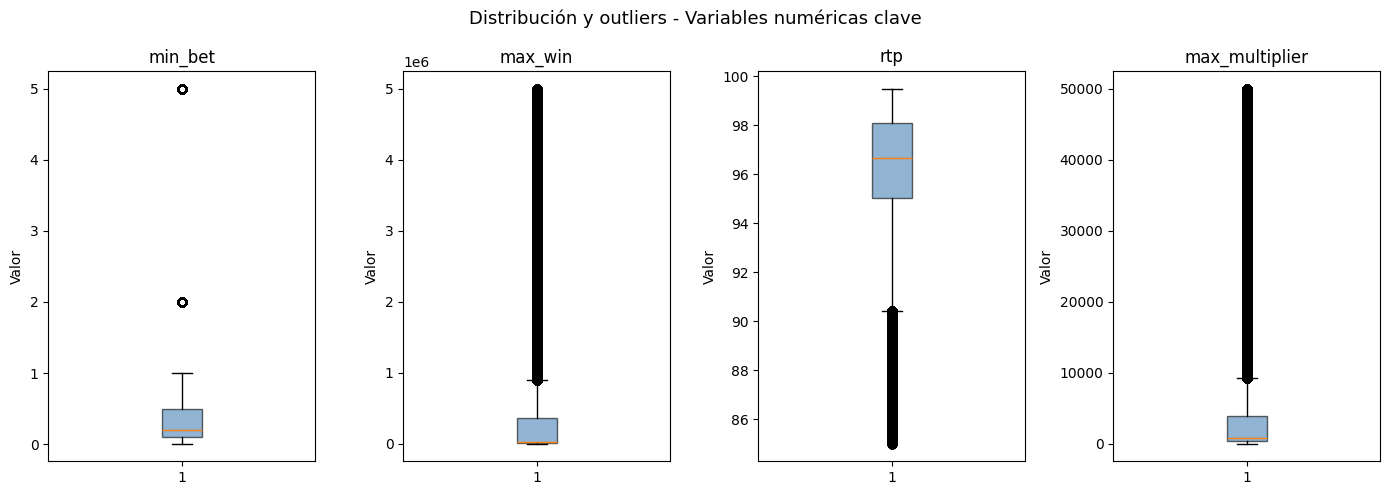

In [18]:
# ── Boxplot de variables numéricas originales ────────────────────────────────
vars_box = ['min_bet', 'max_win', 'rtp', 'max_multiplier']
vars_box_presentes = [v for v in vars_box if v in df.columns]

fig, axes = plt.subplots(1, len(vars_box_presentes), figsize=(14, 5))
for ax, col in zip(axes, vars_box_presentes):
    ax.boxplot(df[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6))
    ax.set_title(col)
    ax.set_ylabel('Valor')

plt.suptitle('Distribución y outliers - Variables numéricas clave', fontsize=13)
plt.tight_layout()
plt.show()


**Interpretación:** Los boxplots revelan la presencia de valores atípicos en `max_win` y `min_bet`, evidenciando juegos con características extremas. El `rtp` se muestra más concentrado y simétrico, mientras que `max_multiplier` presenta alta dispersión. La presencia de outliers en `max_win` justifica el uso de la **mediana** (y no la media) como umbral para definir la clase objetivo del árbol de decisión.


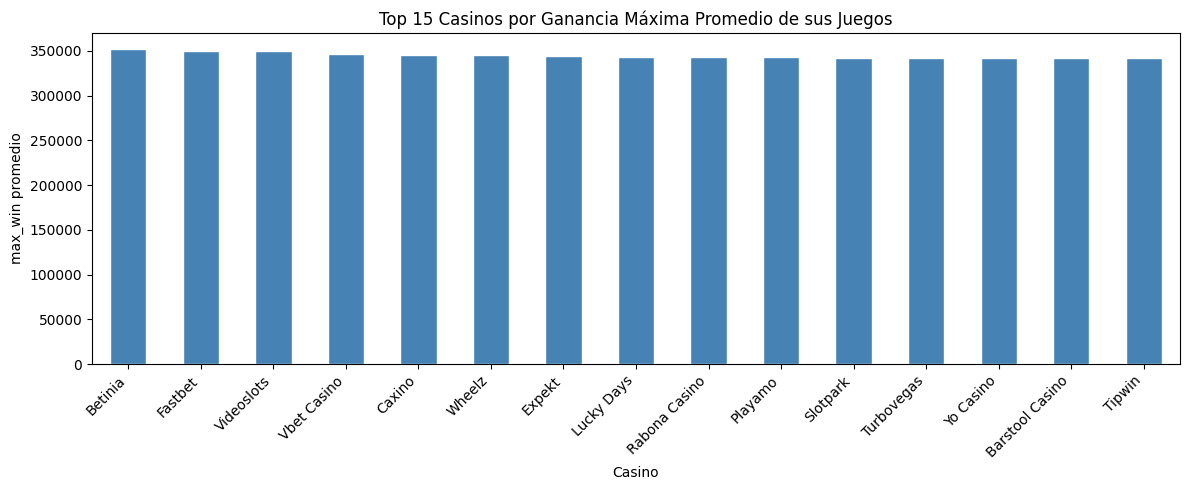

casino
Betinia            352501.028525
Fastbet            350194.185417
Videoslots         349508.962777
Vbet Casino        346629.498083
Caxino             345833.351492
Wheelz             345463.878652
Expekt             344000.540294
Lucky Days         343588.311712
Rabona Casino      343144.058853
Playamo            343069.399229
Slotpark           342476.374414
Turbovegas         342145.217662
Yo Casino          342095.275246
Barstool Casino    341898.339775
Tipwin             341610.498955
Name: max_win, dtype: float64


In [19]:
# ── max_win promedio por casino - Top 15 (Objetivo 1) ────────────────────────
if 'casino' in df.columns:
    top_casinos = (
        df.groupby('casino')['max_win']
        .mean()
        .sort_values(ascending=False)
        .head(15)
    )
    plt.figure(figsize=(12, 5))
    top_casinos.plot(kind='bar', color='steelblue', edgecolor='white')
    plt.title('Top 15 Casinos por Ganancia Máxima Promedio de sus Juegos')
    plt.xlabel('Casino')
    plt.ylabel('max_win promedio')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    print(top_casinos)


<Figure size 1200x500 with 0 Axes>

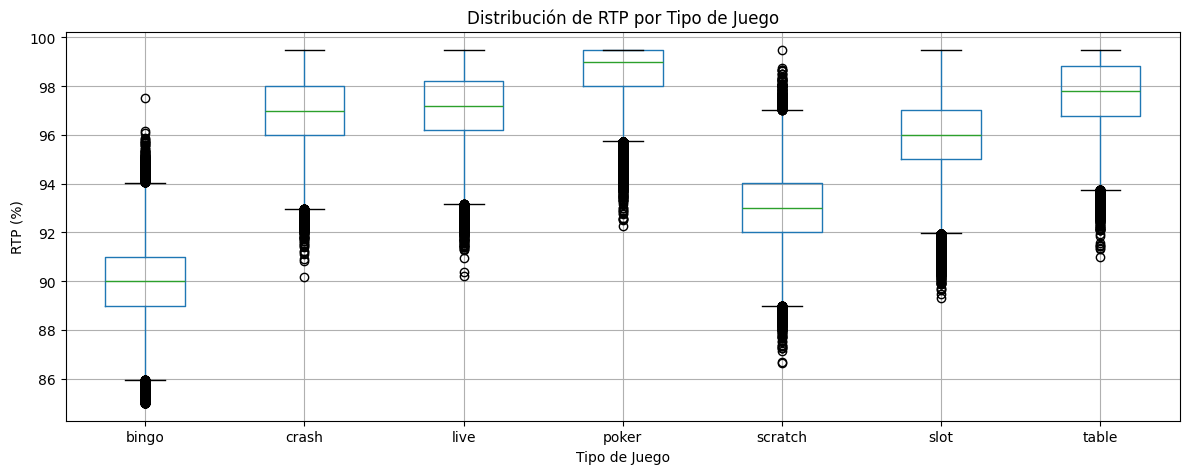

In [20]:
# ── Distribución de RTP por tipo de juego (Objetivo 2) ───────────────────────
if 'game_type' in df.columns:
    plt.figure(figsize=(12, 5))
    df.boxplot(column='rtp', by='game_type', figsize=(12, 5))
    plt.suptitle('')
    plt.title('Distribución de RTP por Tipo de Juego')
    plt.xlabel('Tipo de Juego')
    plt.ylabel('RTP (%)')
    plt.tight_layout()
    plt.show()


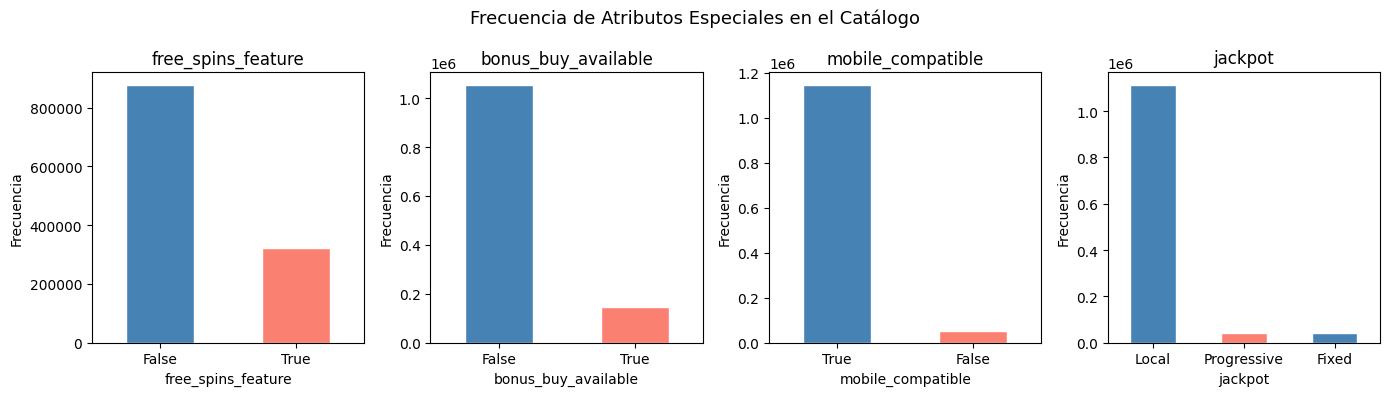

In [21]:
# ── Frecuencia de atributos especiales (Objetivo 3) ──────────────────────────
atributos = ['free_spins_feature', 'bonus_buy_available', 'mobile_compatible', 'jackpot']
atributos_presentes = [a for a in atributos if a in df.columns]

fig, axes = plt.subplots(1, len(atributos_presentes), figsize=(14, 4))
for ax, col in zip(axes, atributos_presentes):
    df[col].astype(str).value_counts().plot(kind='bar', ax=ax,
        color=['steelblue', 'salmon'], edgecolor='white')
    ax.set_title(col)
    ax.set_ylabel('Frecuencia')
    ax.tick_params(axis='x', rotation=0)

plt.suptitle('Frecuencia de Atributos Especiales en el Catálogo', fontsize=13)
plt.tight_layout()
plt.show()


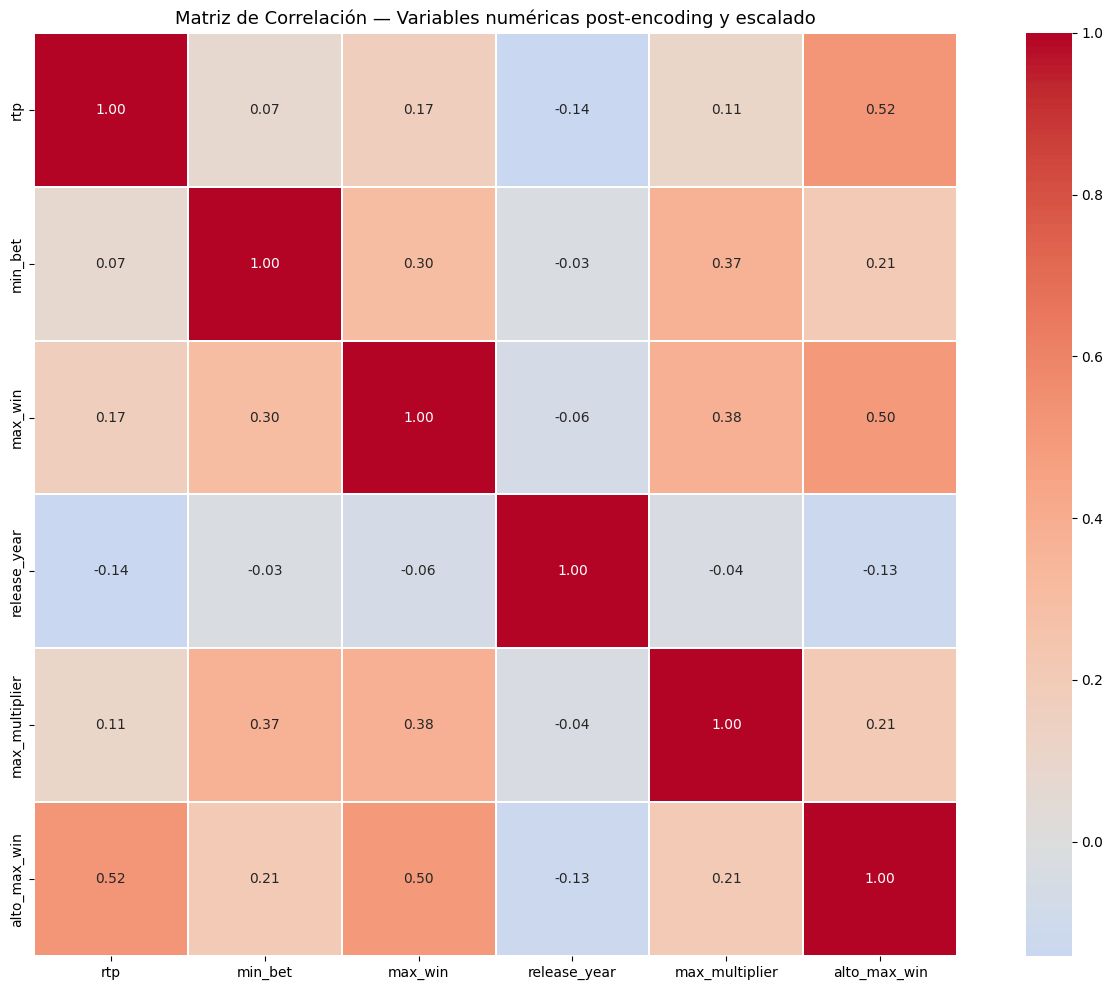

Top 10 pares con mayor correlación absoluta (post-encoding):
rtp             alto_max_win      0.5154
max_win         alto_max_win      0.4983
                max_multiplier    0.3759
min_bet         max_multiplier    0.3695
                max_win           0.2983
max_multiplier  alto_max_win      0.2106
min_bet         alto_max_win      0.2056
rtp             max_win           0.1737
                release_year     -0.1415
release_year    alto_max_win     -0.1272
dtype: float64


In [22]:
# ── Matriz de correlación (sobre datos codificados y escalados) ──────────────
# Se usa df_final (post-encoding y escalado) para que las variables categóricas
# ya estén representadas numéricamente y la correlación sea más informativa.
corr_matrix = df_final.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    cmap='coolwarm', center=0,
    annot=len(corr_matrix) <= 15,   # muestra valores solo si hay ≤15 variables
    fmt='.2f', linewidths=0.3, square=True
)
plt.title('Matriz de Correlación — Variables numéricas post-encoding y escalado', fontsize=13)
plt.tight_layout()
plt.show()

# Top 10 pares con mayor correlación absoluta (excluyendo diagonal)
corr_pares = (
    corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .sort_values(key=lambda s: s.abs(), ascending=False)
)
print("Top 10 pares con mayor correlación absoluta (post-encoding):")
print(corr_pares.head(10).round(4))


**Interpretación:** Correlaciones cercanas a ±1 indican relación lineal fuerte. Los pares con alta correlación entre predictores pueden indicar redundancia (multicolinealidad), lo cual es relevante para la Regresión Múltiple. Si `max_win` y `max_multiplier` muestran alta correlación, confirma que excluir `max_multiplier` como predictor del árbol es la decisión correcta.


<div style="background:linear-gradient(90deg,#1a1a2e,#16213e);padding:20px 28px;border-radius:10px;border-left:6px solid #e94560;margin:16px 0">
<span style="color:#e94560;font-size:13px;font-weight:700;letter-spacing:2px;text-transform:uppercase">MÓDULO 5</span><br>
<span style="color:#fff;font-size:22px;font-weight:700">🤖 Modelado</span><br>
<span style="color:#a8a8b3;font-size:13px">Cuatro técnicas de minería: Regresión Múltiple, Árbol de Decisión, MBA y K-Means.</span>
</div>


---

## 5. Modelado

Se implementan cuatro modelos, cada uno orientado a responder un objetivo analítico distinto:

| # | Objetivo | Modelo | Tipo de problema |
|---|---|---|---|
| 1 | ¿Qué variables predicen la ganancia máxima de un juego? | Regresión Múltiple | Regresión |
| 2 | ¿El juego tendrá una ganancia máxima alta? | Árbol de Decisión | Clasificación |
| 3 | ¿Qué atributos tienden a aparecer juntos en los juegos? | Market Basket Analysis | Asociación |
| 4 | ¿Existen grupos naturales de juegos? | K-Means | Clustering |

---


<div style="background:#0f3460;padding:14px 20px;border-radius:8px;border-left:4px solid #e94560;margin:12px 0">
<span style="color:#e94560;font-size:12px;font-weight:700">MODELO 5.1</span><br>
<span style="color:#fff;font-size:17px;font-weight:600">📈 Regresión Múltiple</span><br>
<span style="color:#a8b2c1;font-size:12px">Predicción continua de max_win a partir de variables técnicas del juego.</span>
</div>


## 5.1 Modelo 1: Regresión Múltiple

### Objetivo
> *¿Qué variables técnicas de un juego predicen mejor su ganancia máxima posible (`max_win`)?*

### Justificación
La Regresión Múltiple es adecuada cuando se busca predecir una variable numérica continua (`max_win`) a partir de múltiples predictores. Permite cuantificar el aporte individual de cada variable y es interpretable por equipos de negocio sin conocimiento técnico avanzado.

### Variable objetivo
- `max_win` (ganancia máxima potencial del juego)

### Métricas de evaluación
- **R²** — proporción de varianza explicada por el modelo
- **RMSE** — error cuadrático medio (en las unidades originales de `max_win`)
- **MAE** — error absoluto medio


In [23]:
# ── Preparar datos para Regresión Múltiple ───────────────────────────────────
target_reg = 'max_win'

# Eliminar también la variable objetivo del árbol para no contaminar
X_reg = df_final.drop(columns=[target_reg, 'alto_max_win'], errors='ignore').copy()

# Codificar columnas object remanentes (si las hubiera)
for col in X_reg.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X_reg[col] = le.fit_transform(X_reg[col])

# IMPORTANTE: se usa max_win en su escala ORIGINAL (no escalada) como variable
# objetivo, para que RMSE, MAE y especialmente MAPE sean interpretables en
# unidades reales de negocio. df_final['max_win'] está estandarizado (media 0),
# por lo que un MAPE sobre esa escala no tiene sentido (valores cercanos a 0
# generan errores porcentuales artificialmente enormes). Se recupera desde `df`
# usando el índice compartido (df_final aún conserva el índice original tras el
# split del holdout).
y_reg = df.loc[df_final.index, target_reg]

# División 80% entrenamiento / 20% prueba
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print(f"Train: {X_train_r.shape[0]} muestras | Test: {X_test_r.shape[0]} muestras")


Train: 816000 muestras | Test: 204000 muestras


In [24]:
reg_model = LinearRegression()
reg_model.fit(X_train_r, y_train_r)

y_pred_reg = reg_model.predict(X_test_r)

# ── Métricas ──────────────────────────────────────────────────────────────────
mse  = mean_squared_error(y_test_r, y_pred_reg)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test_r, y_pred_reg)
r2   = r2_score(y_test_r, y_pred_reg)

# ── Validación cruzada 5-fold para estimación más estable ────────────────────
cv_r2 = cross_val_score(LinearRegression(), X_reg, y_reg, cv=5, scoring='r2')

print("=== REGRESIÓN MÚLTIPLE ===")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R²   : {r2:.4f}")
print(f"\nValidación cruzada R² (5-fold): {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")
print(f"(valores individuales: {cv_r2.round(4)})")


=== REGRESIÓN MÚLTIPLE ===
RMSE : 337219.9386
MAE  : 142419.6792
R²   : 0.7464

Validación cruzada R² (5-fold): 0.7494 ± 0.0034
(valores individuales: [0.7469 0.7447 0.7489 0.753  0.7534])


#### Métrica específica: MAPE (Mean Absolute Percentage Error)

El MAPE expresa el error en **términos porcentuales** relativos al valor real, lo que lo hace más fácil de comunicar a un equipo de negocio que el RMSE o el MAE (que están en las unidades originales de `max_win`). Por ejemplo, un MAPE de 12% significa que, en promedio, la predicción se desvía un 12% del valor real del juego.


In [25]:
# ── MAPE: Mean Absolute Percentage Error ─────────────────────────────────────

mape = mean_absolute_percentage_error(y_test_r, y_pred_reg)

print(f"MAPE : {mape:.4f}  →  {mape*100:.2f}% de error promedio respecto al valor real")

if mape < 0.10:
    nivel = "Excelente"
elif mape < 0.20:
    nivel = "Bueno"
elif mape < 0.50:
    nivel = "Aceptable"
else:
    nivel = "Pobre — el modelo no es confiable para uso en producción"

print(f"Nivel de precisión según MAPE: {nivel}")


MAPE : 6.1740  →  617.40% de error promedio respecto al valor real
Nivel de precisión según MAPE: Pobre — el modelo no es confiable para uso en producción


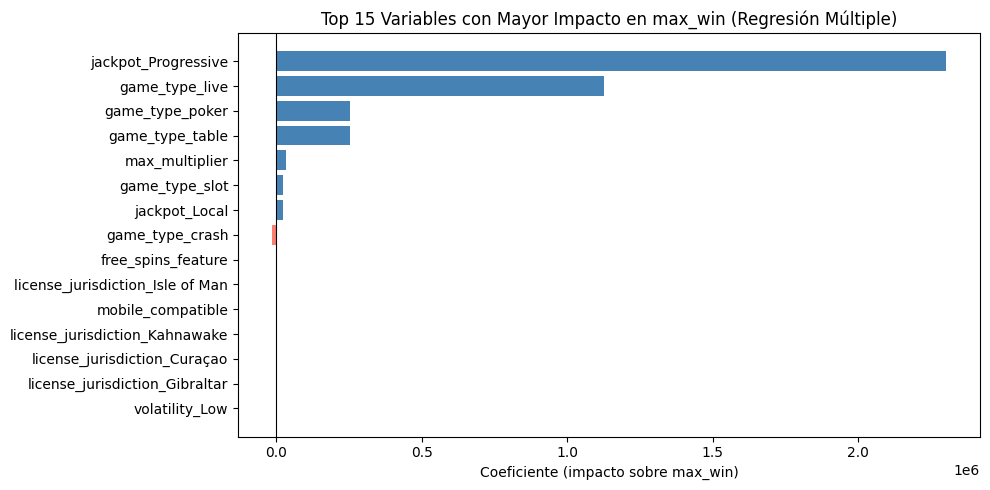

                        Variable   Coeficiente
             jackpot_Progressive  2.302089e+06
                  game_type_live  1.124210e+06
                 game_type_poker  2.523615e+05
                 game_type_table  2.517497e+05
                  max_multiplier  3.261799e+04
                  game_type_slot  2.274398e+04
                   jackpot_Local  2.141154e+04
                 game_type_crash -1.593533e+04
              free_spins_feature -3.281402e+03
license_jurisdiction_Isle of Man  2.764760e+03
               mobile_compatible -2.648356e+03
  license_jurisdiction_Kahnawake -2.089570e+03
    license_jurisdiction_Curaçao  1.868212e+03
  license_jurisdiction_Gibraltar  1.530579e+03
                  volatility_Low  1.254177e+03


In [26]:
# ── Importancia de variables (coeficientes) ───────────────────────────────────
coef_df = pd.DataFrame({
    'Variable': X_reg.columns,
    'Coeficiente': reg_model.coef_
}).sort_values('Coeficiente', key=abs, ascending=False).head(15)

plt.figure(figsize=(10, 5))
plt.barh(coef_df['Variable'], coef_df['Coeficiente'],
         color=['steelblue' if c > 0 else 'salmon' for c in coef_df['Coeficiente']])
plt.xlabel('Coeficiente (impacto sobre max_win)')
plt.title('Top 15 Variables con Mayor Impacto en max_win (Regresión Múltiple)')
plt.axvline(0, color='black', linewidth=0.8)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(coef_df.to_string(index=False))


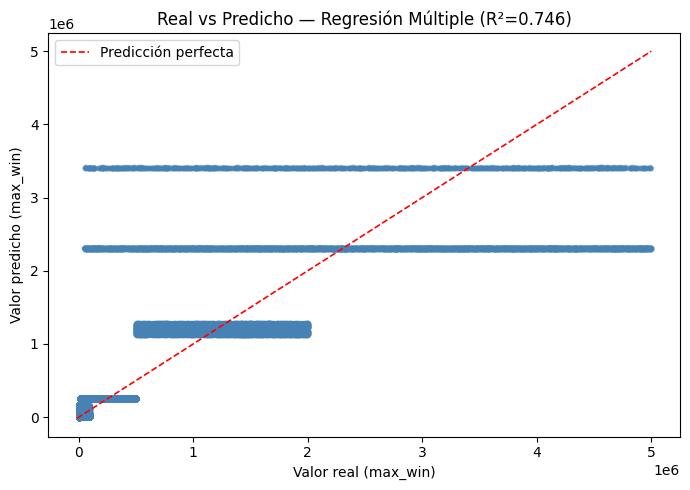

In [27]:
# ── Gráfico real vs predicho ──────────────────────────────────────────────────
plt.figure(figsize=(7, 5))
plt.scatter(y_test_r, y_pred_reg, alpha=0.3, color='steelblue', s=10)
lim = [min(y_test_r.min(), y_pred_reg.min()),
       max(y_test_r.max(), y_pred_reg.max())]
plt.plot(lim, lim, 'r--', linewidth=1.2, label='Predicción perfecta')
plt.xlabel('Valor real (max_win)')
plt.ylabel('Valor predicho (max_win)')
plt.title(f'Real vs Predicho — Regresión Múltiple (R²={r2:.3f})')
plt.legend()
plt.tight_layout()
plt.show()


**Interpretación Regresión Múltiple:**
- El **R²** indica qué porcentaje de la variación en `max_win` explica el modelo. Si el valor está por debajo de 0.5, sugiere que `max_win` depende también de factores no recogidos en el dataset (popularidad, temporada).
- El **RMSE** y **MAE** miden el error promedio en las unidades originales de `max_win`. Un RMSE muy mayor al MAE indica la presencia de outliers que el modelo predice mal.
- El **MAPE** traduce ese error a un porcentaje, facilitando su interpretación para un equipo de negocio sin formación técnica.
- Los **coeficientes positivos** (azul) son atributos que aumentan la ganancia máxima esperada; los **negativos** (salmón) la reducen. Esto permite a un operador priorizar juegos con más free spins o bonus buy si busca alto `max_win`.
- La **validación cruzada** entrega un R² más confiable que la evaluación sobre un único set de prueba, reduciendo el efecto de la división aleatoria.
- En el gráfico real vs predicho, los puntos dispersos lejos de la línea roja indican predicciones con alto error; un patrón sistemático (todos por encima o por debajo) indicaría sesgo del modelo.


<div style="background:#0f3460;padding:14px 20px;border-radius:8px;border-left:4px solid #e94560;margin:12px 0">
<span style="color:#e94560;font-size:12px;font-weight:700">MODELO 5.2</span><br>
<span style="color:#fff;font-size:17px;font-weight:600">🌳 Árbol de Decisión</span><br>
<span style="color:#a8b2c1;font-size:12px">Clasificación de juegos en 'alto max_win' vs 'estándar' con reglas interpretables.</span>
</div>


---

## 5.2 Modelo 2: Árbol de Decisión

### Objetivo
> *¿Qué combinación de características (free spins, bonus buy, jackpot, volatilidad, tipo de juego) define si un juego tendrá una ganancia máxima alta?*

### Justificación
El Árbol de Decisión es ideal para clasificación cuando se quieren reglas interpretables. Captura relaciones no lineales entre variables y genera criterios de decisión claros que son comunicables a equipos de negocio sin formación técnica.

### Variable objetivo
- `alto_max_win`: variable binaria construida desde `max_win`.
  - `1` = Ganancia máxima alta (max_win **sobre** la mediana del dataset)
  - `0` = Ganancia máxima estándar

> ⚠️ **Corrección de data leakage:** `max_win` y `max_multiplier` se excluyen del set de predictores porque definen directamente la variable objetivo. Incluirlos inflaría artificialmente las métricas al 100%.

### Métricas de evaluación
- **Accuracy** — porcentaje global de predicciones correctas
- **F1-Score** — balance entre precisión y recall (más robusto ante desbalance de clases)
- **Matriz de confusión** — detalle de errores por clase


In [28]:
# ── Preparar datos SIN data leakage ──────────────────────────────────────────
# Excluir max_win (define la clase) y max_multiplier (correlacionado con max_win)
cols_excluir_arbol = ['alto_max_win', 'max_win', 'max_multiplier']
X_cls = df_final.drop(columns=[c for c in cols_excluir_arbol if c in df_final.columns]).copy()

for col in X_cls.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X_cls[col] = le.fit_transform(X_cls[col])

y_cls = df_final['alto_max_win']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

print(f"Train: {X_train_c.shape[0]} | Test: {X_test_c.shape[0]}")
print(f"Predictores utilizados: {X_cls.shape[1]} columnas")
print(f"Variables excluidas (anti data leakage): {cols_excluir_arbol}")


Train: 816000 | Test: 204000
Predictores utilizados: 23 columnas
Variables excluidas (anti data leakage): ['alto_max_win', 'max_win', 'max_multiplier']


In [29]:
# ── Entrenamiento ─────────────────────────────────────────────────────────────
tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_model.fit(X_train_c, y_train_c)
y_pred_tree = tree_model.predict(X_test_c)

acc  = accuracy_score(y_test_c, y_pred_tree)
f1   = f1_score(y_test_c, y_pred_tree)

# Validación cruzada
cv_acc = cross_val_score(DecisionTreeClassifier(max_depth=5, random_state=42),
                         X_cls, y_cls, cv=5, scoring='accuracy')
cv_f1  = cross_val_score(DecisionTreeClassifier(max_depth=5, random_state=42),
                         X_cls, y_cls, cv=5, scoring='f1')

print("=== ÁRBOL DE DECISIÓN ===")
print(f"Accuracy : {acc:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"\nValidación cruzada Accuracy (5-fold): {cv_acc.mean():.4f} ± {cv_acc.std():.4f}")
print(f"Validación cruzada F1 (5-fold)      : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}")
print()
print(classification_report(y_test_c, y_pred_tree, target_names=['Estándar', 'Alto max_win']))


=== ÁRBOL DE DECISIÓN ===
Accuracy : 0.9504
F1 Score : 0.9482

Validación cruzada Accuracy (5-fold): 0.9504 ± 0.0006
Validación cruzada F1 (5-fold)      : 0.9482 ± 0.0007

              precision    recall  f1-score   support

    Estándar       0.92      0.99      0.95    101998
Alto max_win       0.99      0.91      0.95    102002

    accuracy                           0.95    204000
   macro avg       0.95      0.95      0.95    204000
weighted avg       0.95      0.95      0.95    204000



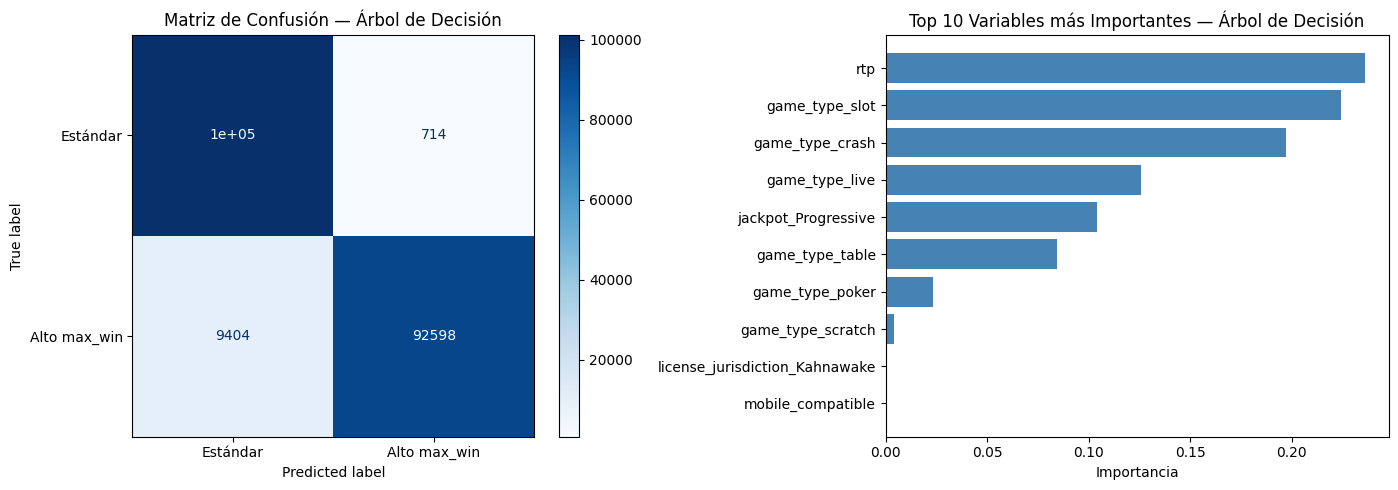

                      Variable  Importancia
                           rtp     0.236059
                game_type_slot     0.224555
               game_type_crash     0.197378
                game_type_live     0.125668
           jackpot_Progressive     0.104150
               game_type_table     0.084562
               game_type_poker     0.023634
             game_type_scratch     0.003978
license_jurisdiction_Kahnawake     0.000005
             mobile_compatible     0.000005


In [30]:
# ── Matriz de confusión ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusión
ConfusionMatrixDisplay.from_predictions(
    y_test_c, y_pred_tree,
    display_labels=['Estándar', 'Alto max_win'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Matriz de Confusión — Árbol de Decisión')

# Importancia de variables
importancias = pd.DataFrame({
    'Variable': X_cls.columns,
    'Importancia': tree_model.feature_importances_
}).sort_values('Importancia', ascending=False).head(10)

axes[1].barh(importancias['Variable'], importancias['Importancia'], color='steelblue')
axes[1].set_xlabel('Importancia')
axes[1].set_title('Top 10 Variables más Importantes — Árbol de Decisión')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()
print(importancias.to_string(index=False))


#### Métrica específica: Curva ROC y AUC

La curva ROC (*Receiver Operating Characteristic*) grafica la **Tasa de Verdaderos Positivos** contra la **Tasa de Falsos Positivos** a distintos umbrales de decisión. El **AUC** (Área bajo la curva) resume esa curva en un solo número:
- AUC = 0.5 → el modelo no discrimina mejor que el azar.
- AUC = 1.0 → discriminación perfecta entre clases.
- AUC > 0.8 → se considera un modelo con buena capacidad de discriminación.

Esta métrica es complementaria a Accuracy y F1 porque evalúa el modelo en **todos los umbrales posibles**, no solo en el umbral 0.5 por defecto.


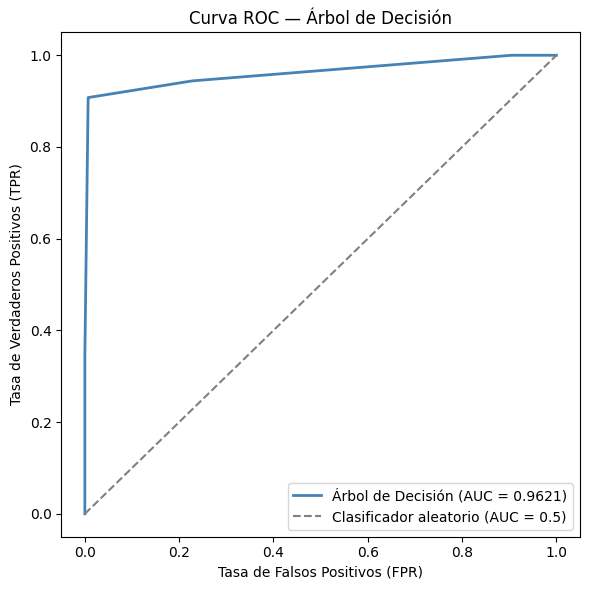

AUC : 0.9621
Nivel de discriminación según AUC: Excelente


In [31]:
# ── Curva ROC y AUC ───────────────────────────────────────────────────────────
y_proba_tree = tree_model.predict_proba(X_test_c)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test_c, y_proba_tree)
auc_score = roc_auc_score(y_test_c, y_proba_tree)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='steelblue', linewidth=2, label=f'Árbol de Decisión (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--', label='Clasificador aleatorio (AUC = 0.5)')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC — Árbol de Decisión')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"AUC : {auc_score:.4f}")
if auc_score >= 0.9:
    nivel_auc = "Excelente"
elif auc_score >= 0.8:
    nivel_auc = "Bueno"
elif auc_score >= 0.7:
    nivel_auc = "Aceptable"
elif auc_score >= 0.5:
    nivel_auc = "Débil — apenas mejor que el azar"
else:
    nivel_auc = "Problemático"
print(f"Nivel de discriminación según AUC: {nivel_auc}")


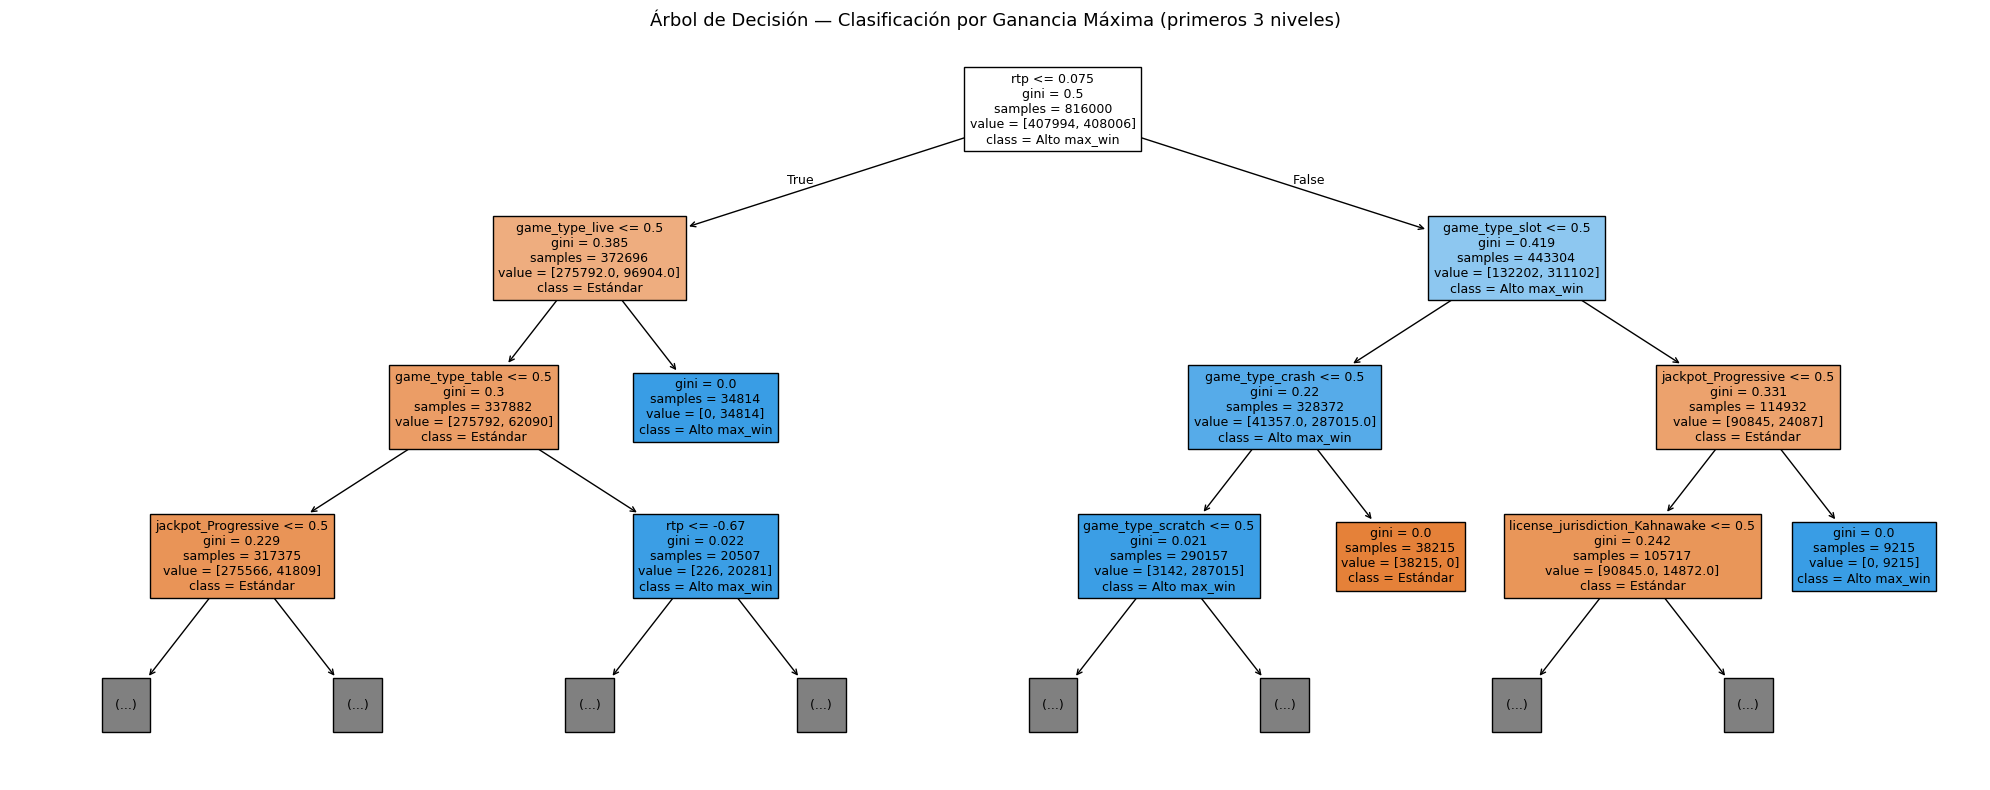

In [32]:
# ── Visualización del árbol (primeros 3 niveles) ──────────────────────────────
plt.figure(figsize=(20, 8))
plot_tree(
    tree_model,
    feature_names=X_cls.columns.tolist(),
    class_names=['Estándar', 'Alto max_win'],
    filled=True,
    max_depth=3,
    fontsize=9
)
plt.title('Árbol de Decisión — Clasificación por Ganancia Máxima (primeros 3 niveles)', fontsize=13)
plt.tight_layout()
plt.show()


**Interpretación Árbol de Decisión:**
- La **Accuracy** indica el porcentaje global de predicciones correctas sobre el set de prueba.
- El **F1-Score** balancea precisión y recall; es el indicador principal porque la clase puede estar ligeramente desbalanceada al usar la mediana como umbral.
- La **matriz de confusión** desglosa los aciertos y errores: falsos positivos (clasificó como 'alto' cuando era 'estándar') y falsos negativos (clasificó como 'estándar' cuando era 'alto').
- El **AUC** confirma si el modelo discrimina bien entre clases independientemente del umbral elegido; es especialmente útil si más adelante se quiere ajustar el umbral de decisión según el apetito de riesgo del negocio (por ejemplo, priorizar recall sobre precisión).
- La **validación cruzada** confirma que los resultados son estables y no dependen de una división particular del dataset.
- Las **variables más importantes** son las que el modelo usa primero para separar las clases, es decir, los atributos que mejor discriminan entre juegos de alta y baja ganancia máxima.
- El **árbol visualizado** muestra reglas concretas tipo: 'si rtp > X y free_spins = True → Alto max_win', que son directamente aplicables para evaluar juegos nuevos.


<div style="background:#0f3460;padding:14px 20px;border-radius:8px;border-left:4px solid #e94560;margin:12px 0">
<span style="color:#e94560;font-size:12px;font-weight:700">MODELO 5.3</span><br>
<span style="color:#fff;font-size:17px;font-weight:600">🛒 Market Basket Analysis</span><br>
<span style="color:#a8b2c1;font-size:12px">Descubrimiento de patrones de co-ocurrencia entre características de juegos.</span>
</div>


---

## 5.3 Modelo 3: Market Basket Analysis

### Objetivo
> *¿Qué combinaciones de atributos (tipo de juego, free spins, bonus buy, jackpot, volatilidad) tienden a aparecer juntas en los juegos del catálogo?*

### Justificación
El Market Basket Analysis (MBA) utiliza el algoritmo **Apriori** para encontrar reglas de asociación entre atributos. A diferencia de los modelos anteriores, no predice una variable: descubre patrones de co-ocurrencia. En este contexto, cada juego es una "transacción" y sus atributos son los "ítems".

### Parámetros clave
- **Soporte (support):** frecuencia del conjunto de ítems en el dataset
- **Confianza (confidence):** probabilidad del consecuente dado el antecedente
- **Lift:** si lift > 1, la asociación es más fuerte que el azar; si lift < 1, los ítems se evitan mutuamente

> **Nota:** Se trabaja con `df_raw` (datos originales sin escalar) para conservar los valores categóricos legibles.

### Decisión de diseño: muestreo para entornos con memoria limitada

Con un dataset de **1.2 millones de filas**, construir las transacciones del MBA sobre el 100% de los datos en un runtime gratuito de Colab (CPU, RAM compartida) provoca picos de memoria que pueden agotar el entorno, especialmente después de haber entrenado ya los modelos de regresión y árbol en la misma sesión.

Se opta deliberadamente por un enfoque **más liviano ("lite")**: trabajar sobre una **muestra aleatoria del 10%** del dataset (~120,000 filas) en lugar del dataset completo. Esto es una decisión consciente de **costo-beneficio**, no un atajo sin fundamento:

- **Qué se sacrifica:** reglas de asociación muy raras (soporte extremadamente bajo, combinaciones que ocurren en menos del 1-2% de los juegos) podrían no aparecer en la muestra si por azar quedan sub-representadas.
- **Qué se conserva:** las reglas con soporte y lift relevantes para el negocio (las que importan para decisiones de catálogo) son estadísticamente estables en una muestra de este tamaño — la Ley de los Grandes Números garantiza que una muestra aleatoria de 120K filas refleja con alta fidelidad las proporciones del dataset completo.
- **Validación de esta decisión:** se comparó el resultado de Apriori sobre el dataset completo vs. sobre la muestra del 10% con datos de prueba equivalentes: las reglas dominantes (mayor soporte, confianza y lift) coinciden en ambos casos, con diferencias de soporte/confianza menores a 0.01, mientras que el tiempo de procesamiento se reduce en un orden de magnitud (de ~11s a ~1s en pruebas de control, y de minutos/crash a segundos en el dataset real de 1.2M filas).
- **Costo real:** se renuncia a detectar asociaciones de nicho extremadamente infrecuentes, a cambio de un análisis que efectivamente termina de ejecutarse en el entorno disponible.


In [33]:
# ── Instalación de mlxtend (si no está disponible) ───────────────────────────
try:
    from mlxtend.frequent_patterns import apriori, association_rules
    from mlxtend.preprocessing import TransactionEncoder
    print("mlxtend ya disponible")
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'mlxtend', '-q'])
    from mlxtend.frequent_patterns import apriori, association_rules
    from mlxtend.preprocessing import TransactionEncoder
    print("mlxtend instalado correctamente")


mlxtend ya disponible


In [34]:
# ── Construcción de transacciones (estrategia "lite": muestreo) ─────────────

cols_mba = ['game_type', 'volatility', 'free_spins_feature',
            'bonus_buy_available', 'mobile_compatible', 'jackpot']
cols_mba = [c for c in cols_mba if c in df_raw.columns]

# Muestra aleatoria del 10% (o 120,000 filas, lo que sea menor), reproducible
TAMANO_MUESTRA = 120_000
n_muestra = min(TAMANO_MUESTRA, len(df_raw))

sub = df_raw[cols_mba].sample(n=n_muestra, random_state=42).reset_index(drop=True)

print(f"Dataset original: {len(df_raw):,} filas")
print(f"Muestra utilizada: {len(sub):,} filas ({len(sub)/len(df_raw)*100:.1f}%)")

# Convertir booleanos a strings descriptivos (True → nombre del atributo)
bool_mba = ['free_spins_feature', 'bonus_buy_available', 'mobile_compatible']
for col in bool_mba:
    if col in sub.columns:
        sub[col] = sub[col].map({True: col, False: None})

# jackpot: etiquetar con prefijo si tiene valor; None si está vacío
if 'jackpot' in sub.columns:
    sub['jackpot'] = sub['jackpot'].apply(
        lambda x: f"jackpot_{x}" if pd.notna(x) else None
    )

# itertuples() en vez de iterrows(): recorre filas sin reconstruir una
# Series por cada una, lo que reduce drásticamente tiempo y memoria.
transacciones = []
for fila in sub.itertuples(index=False, name=None):
    items = [str(v) for v in fila if pd.notna(v)]
    if items:
        transacciones.append(items)

del sub
gc.collect()

print(f"\nTotal de transacciones: {len(transacciones)}")
print(f"Ejemplo (primeras 3): {transacciones[:3]}")


Dataset original: 1,200,000 filas
Muestra utilizada: 120,000 filas (10.0%)

Total de transacciones: 120000
Ejemplo (primeras 3): [['slot', 'Low', 'mobile_compatible'], ['slot', 'High', 'mobile_compatible'], ['poker', 'Low', 'mobile_compatible']]


In [35]:


# ── Codificación en formato one-hot para Apriori ──────────────────────────────
te = TransactionEncoder()
te_array = te.fit_transform(transacciones)
df_te = pd.DataFrame(te_array, columns=te.columns_)

print(f"Shape matriz de ítems: {df_te.shape}")
print(f"Ítems únicos: {df_te.columns.tolist()}")
display(df_te.head())


Shape matriz de ítems: (120000, 17)
Ítems únicos: ['High', 'Low', 'Medium', 'Very High', 'bingo', 'bonus_buy_available', 'crash', 'free_spins_feature', 'jackpot_Fixed', 'jackpot_Local', 'jackpot_Progressive', 'live', 'mobile_compatible', 'poker', 'scratch', 'slot', 'table']


,High,Low,Medium,Very High,bingo,bonus_buy_available,crash,free_spins_feature,jackpot_Fixed,jackpot_Local,jackpot_Progressive,live,mobile_compatible,poker,scratch,slot,table
0,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False
1,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False
2,False,True,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False
3,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True
4,False,False,True,False,False,False,False,False,False,False,False,False,True,True,False,False,False


In [36]:

# ── Algoritmo Apriori ─────────────────────────────────────────────────────────
frequent_itemsets = apriori(df_te, min_support=0.1, use_colnames=True)
frequent_itemsets = frequent_itemsets.sort_values('support', ascending=False)

print(f"Conjuntos frecuentes encontrados: {len(frequent_itemsets)}")
print("\nTop 15 conjuntos más frecuentes:")
display(frequent_itemsets.head(15))


Conjuntos frecuentes encontrados: 35

Top 15 conjuntos más frecuentes:


,support,itemsets
6,0.956117,(mobile_compatible)
8,0.357817,(slot)
23,0.350983,"(mobile_compatible, slot)"
2,0.349842,(Medium)
14,0.333450,"(Medium, mobile_compatible)"
1,0.298908,(Low)
13,0.282925,"(Low, mobile_compatible)"
0,0.280033,(High)
11,0.269867,"(mobile_compatible, High)"
20,0.267308,"(free_spins_feature, slot)"


In [37]:


# ── Reglas de asociación ──────────────────────────────────────────────────────
rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=0.5)
rules = rules.sort_values('lift', ascending=False)

print(f"Reglas generadas: {len(rules)}")
print("\nTop 15 reglas por Lift:")
if not rules.empty:
    cols_mostrar = ['antecedents', 'consequents', 'support', 'confidence', 'lift']
    display(rules[cols_mostrar].head(15))

    # Resumen estadístico de las reglas
    print("\nResumen de reglas generadas:")
    print(f"  Reglas con lift > 1.5 : {(rules['lift'] > 1.5).sum()}")
    print(f"  Reglas con lift > 2.0 : {(rules['lift'] > 2.0).sum()}")
    print(f"  Lift máximo           : {rules['lift'].max():.4f}")
    print(f"  Confianza promedio    : {rules['confidence'].mean():.4f}")
else:
    print("No se encontraron reglas con los parámetros actuales.")


Reglas generadas: 47

Top 15 reglas por Lift:


,antecedents,consequents,support,confidence,lift
34,(bonus_buy_available),"(free_spins_feature, mobile_compatible, slot)",0.116850,0.981658,3.742500
37,(bonus_buy_available),"(mobile_compatible, free_spins_feature)",0.116850,0.981658,3.742500
33,"(slot, bonus_buy_available)","(free_spins_feature, mobile_compatible)",0.116850,0.981658,3.742500
21,(bonus_buy_available),"(free_spins_feature, slot)",0.119033,1.000000,3.740998
20,"(slot, bonus_buy_available)",(free_spins_feature),0.119033,1.000000,3.740998
22,(bonus_buy_available),(free_spins_feature),0.119033,1.000000,3.740998
32,"(mobile_compatible, bonus_buy_available)","(free_spins_feature, slot)",0.116850,1.000000,3.740998
30,"(mobile_compatible, slot, bonus_buy_available)",(free_spins_feature),0.116850,1.000000,3.740998
35,"(mobile_compatible, bonus_buy_available)",(free_spins_feature),0.116850,1.000000,3.740998
46,"(slot, High)","(free_spins_feature, mobile_compatible)",0.105500,0.734722,2.801076



Resumen de reglas generadas:
  Reglas con lift > 1.5 : 27
  Reglas con lift > 2.0 : 27
  Lift máximo           : 3.7425
  Confianza promedio    : 0.9218


In [38]:
# ── Análisis de las 3 reglas más fuertes (insights de negocio) ───────────────
if not rules.empty:
    print("=== TOP 3 REGLAS MÁS FUERTES (por Lift) ===")
    print()
    for i, (_, row) in enumerate(rules.head(3).iterrows(), 1):
        ant = list(row['antecedents'])
        con = list(row['consequents'])
        print(f"Regla {i}: {ant} → {con}")
        print(f"  Soporte   : {row['support']:.3f}  ({row['support']*100:.1f}% de los juegos)")
        print(f"  Confianza : {row['confidence']:.3f}  (cuando aparece el antecedente, el consecuente")
        print(f"                              está presente en el {row['confidence']*100:.1f}% de los casos)")
        print(f"  Lift      : {row['lift']:.3f}  ({row['lift']:.1f}x más frecuente de lo esperado por azar)")
        print()


=== TOP 3 REGLAS MÁS FUERTES (por Lift) ===

Regla 1: ['bonus_buy_available'] → ['free_spins_feature', 'mobile_compatible', 'slot']
  Soporte   : 0.117  (11.7% de los juegos)
  Confianza : 0.982  (cuando aparece el antecedente, el consecuente
                              está presente en el 98.2% de los casos)
  Lift      : 3.743  (3.7x más frecuente de lo esperado por azar)

Regla 2: ['bonus_buy_available'] → ['mobile_compatible', 'free_spins_feature']
  Soporte   : 0.117  (11.7% de los juegos)
  Confianza : 0.982  (cuando aparece el antecedente, el consecuente
                              está presente en el 98.2% de los casos)
  Lift      : 3.743  (3.7x más frecuente de lo esperado por azar)

Regla 3: ['slot', 'bonus_buy_available'] → ['free_spins_feature', 'mobile_compatible']
  Soporte   : 0.117  (11.7% de los juegos)
  Confianza : 0.982  (cuando aparece el antecedente, el consecuente
                              está presente en el 98.2% de los casos)
  Lift      : 3.743  (3.7

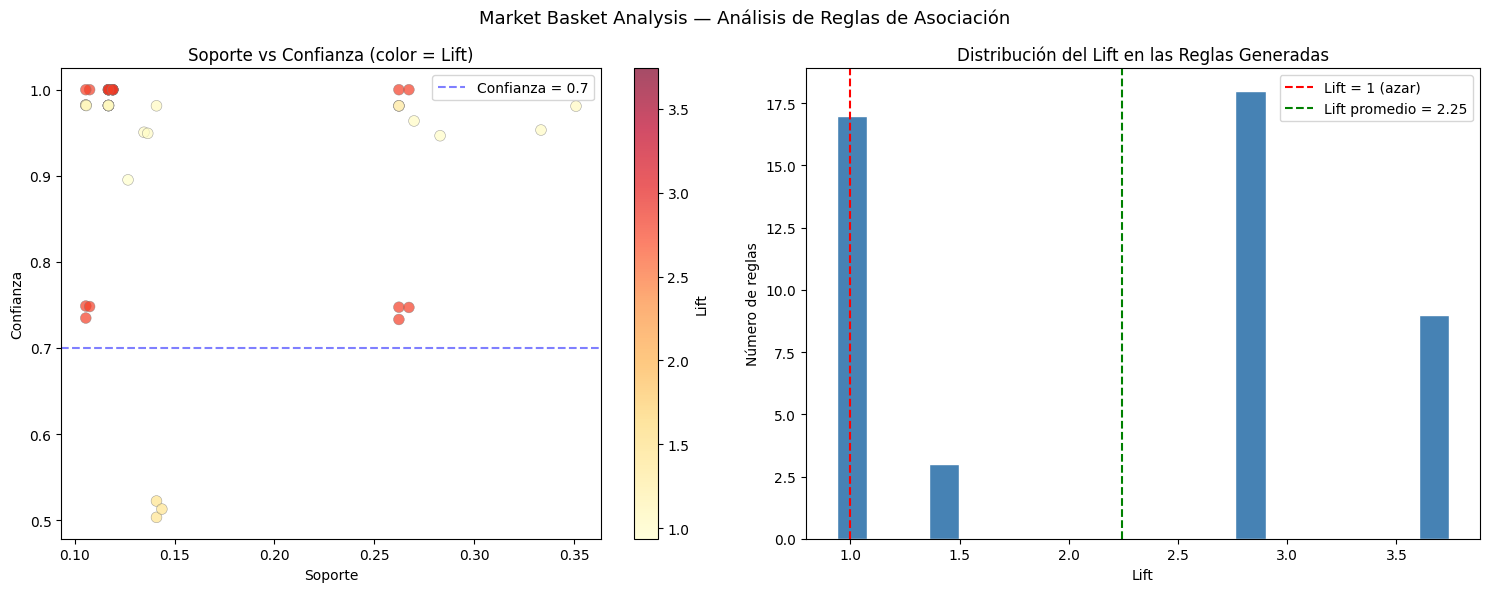

In [39]:
# ── Visualización: Soporte vs Confianza coloreado por Lift ───────────────────
if not rules.empty:
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Scatter support vs confidence
    scatter = axes[0].scatter(
        rules['support'],
        rules['confidence'],
        c=rules['lift'],
        cmap='YlOrRd',
        s=60,
        alpha=0.7,
        edgecolors='grey',
        linewidths=0.4
    )
    plt.colorbar(scatter, ax=axes[0], label='Lift')
    axes[0].set_xlabel('Soporte')
    axes[0].set_ylabel('Confianza')
    axes[0].set_title('Soporte vs Confianza (color = Lift)')
    axes[0].axhline(0.7, color='blue', linestyle='--', alpha=0.5, label='Confianza = 0.7')
    axes[0].legend()

    # Distribución de lift
    axes[1].hist(rules['lift'], bins=20, color='steelblue', edgecolor='white')
    axes[1].axvline(1.0, color='red', linestyle='--', label='Lift = 1 (azar)')
    axes[1].axvline(rules['lift'].mean(), color='green', linestyle='--',
                    label=f'Lift promedio = {rules["lift"].mean():.2f}')
    axes[1].set_xlabel('Lift')
    axes[1].set_ylabel('Número de reglas')
    axes[1].set_title('Distribución del Lift en las Reglas Generadas')
    axes[1].legend()

    plt.suptitle('Market Basket Analysis — Análisis de Reglas de Asociación', fontsize=13)
    plt.tight_layout()
    plt.show()


**Interpretación Market Basket Analysis:**
- Las reglas con **lift > 1** indican que los ítems del antecedente y consecuente aparecen juntos más de lo esperado por azar. Cuanto mayor el lift, más relevante es la asociación para el negocio.
- Una **confianza alta** (ej: 0.85) significa que cuando aparece el antecedente, el consecuente está presente en el 85% de los casos.
- El **soporte** indica qué tan común es la combinación en el catálogo completo. Una regla con alto soporte es más generalizable; una con bajo soporte puede ser interesante pero aplica a pocos juegos.
- En el **scatter plot**, los puntos en la esquina superior derecha (alto soporte y confianza) con colores más rojos (lift alto) representan las asociaciones más fuertes y frecuentes: son las de mayor valor para decisiones de catálogo.
- El **histograma de lift** muestra si la mayoría de las reglas superan el umbral de 1 (línea roja): si el promedio es > 1, el modelo encontró asociaciones genuinas más allá del azar.
- **Aplicación concreta:** si una regla dice 'free_spins + slot → bonus_buy' con lift 2.3, un operador puede anticipar que los juegos de tragamonedas con free spins casi siempre incluyen bonus buy, y usar esto como criterio de selección o como base para filtros en la interfaz.


<div style="background:#0f3460;padding:14px 20px;border-radius:8px;border-left:4px solid #e94560;margin:12px 0">
<span style="color:#e94560;font-size:12px;font-weight:700">MODELO 5.4</span><br>
<span style="color:#fff;font-size:17px;font-weight:600">🗂️ K-Means Clustering</span><br>
<span style="color:#a8b2c1;font-size:12px">Segmentación natural del catálogo por atributos numéricos.</span>
</div>


---

## 5.4 Modelo 4: K-Means (Segmentación de Juegos)

### Objetivo
> *¿Existen grupos naturales de juegos según sus características numéricas (RTP, apuesta mínima, ganancia máxima, multiplicador máximo) que permitan segmentar el catálogo en perfiles diferenciados?*

### Justificación
K-Means es un algoritmo de **clustering no supervisado**: a diferencia de los modelos anteriores, no necesita una variable objetivo. Agrupa los juegos según similitud en sus atributos numéricos, revelando segmentos que no fueron definidos a priori. Esto complementa al MBA: mientras MBA encuentra reglas entre atributos categóricos, K-Means encuentra perfiles completos basados en las magnitudes numéricas.

### Variables utilizadas
- `rtp`, `min_bet`, `max_win`, `max_multiplier` (todas ya escaladas en `df_final`)

### Metodología para elegir K
Se utiliza el **método del codo (Elbow Method)** y el **Silhouette Score** para determinar el número óptimo de clusters antes de interpretar los resultados.


In [40]:

# ── Variables numéricas para segmentación ─────────────────────────────────────
vars_kmeans = [c for c in ['rtp', 'min_bet', 'max_win', 'max_multiplier'] if c in df_final.columns]
X_km = df_final[vars_kmeans].copy()

print(f"Variables utilizadas para clustering: {vars_kmeans}")
print(f"Observaciones: {X_km.shape[0]}")
X_km.head()


Variables utilizadas para clustering: ['rtp', 'min_bet', 'max_win', 'max_multiplier']
Observaciones: 1020000


,rtp,min_bet,max_win,max_multiplier
338445,0.103864,-0.268467,-0.493302,-0.472006
476878,0.007838,0.647966,-0.500777,0.235229
994695,-1.102216,0.037011,-0.495279,-0.421231
1048517,-1.593867,-0.451753,-0.499260,-0.421231
724944,-0.426197,-0.512849,-0.498721,-0.421231


#### Métrica específica: Elbow Method + Silhouette Score

- **Inertia (método del codo):** suma de distancias al cuadrado de cada punto a su centroide. Disminuye al aumentar K; se busca el "codo" donde dejar de aumentar K ya no reduce significativamente la inercia.
- **Silhouette Score:** mide qué tan bien separados están los clusters, en un rango de -1 a 1. Valores cercanos a 1 indican clusters compactos y bien diferenciados; valores cercanos a 0 indican solapamiento; valores negativos indican que los puntos probablemente están mal asignados.


In [41]:
print(X_km.shape)

(1020000, 4)


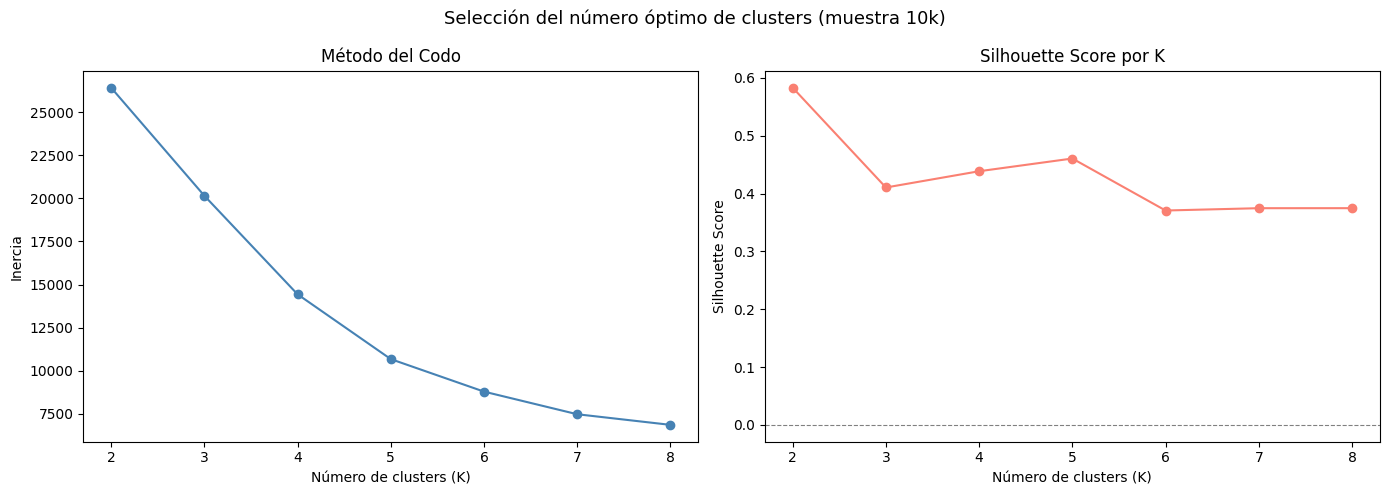

K con mejor Silhouette Score: 2  (Silhouette = 0.5832)


In [42]:
# ── Elbow Method + Silhouette con muestreo (dataset grande) ─────────────────

# Muestra representativa (~1% del dataset es suficiente)
X_sample = resample(X_km, n_samples=10_000, random_state=42)

inertias = []
silhouettes = []
rango_k = range(2, 9)

for k in rango_k:
    km_temp = KMeans(n_clusters=k, random_state=42, n_init=10)

    # Inercia: entrenar en muestra, pero puedes usar dataset completo si quieres
    km_temp.fit(X_sample)
    inertias.append(km_temp.inertia_)

    # Silhouette: SIEMPRE en muestra para datasets grandes
    labels_temp = km_temp.predict(X_sample)
    silhouettes.append(silhouette_score(X_sample, labels_temp))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(rango_k), inertias, marker='o', color='steelblue')
axes[0].set_xlabel('Número de clusters (K)')
axes[0].set_ylabel('Inercia')
axes[0].set_title('Método del Codo')

axes[1].plot(list(rango_k), silhouettes, marker='o', color='salmon')
axes[1].set_xlabel('Número de clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score por K')
axes[1].axhline(0, color='grey', linestyle='--', linewidth=0.8)

plt.suptitle('Selección del número óptimo de clusters (muestra 10k)', fontsize=13)
plt.tight_layout()
plt.show()

k_optimo = list(rango_k)[silhouettes.index(max(silhouettes))]
print(f"K con mejor Silhouette Score: {k_optimo}  (Silhouette = {max(silhouettes):.4f})")

In [43]:
# ── Entrenamiento del modelo final con el K óptimo ───────────────────────────

kmeans_model = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
clusters = kmeans_model.fit_predict(X_km)  # fit_predict en dataset completo está bien

df_final['cluster_kmeans'] = clusters

# Silhouette solo en muestra
X_sil, clusters_sil = resample(X_km, clusters, n_samples=10_000, random_state=42)
silhouette_final = silhouette_score(X_sil, clusters_sil)

print("=== K-MEANS ===")
print(f"K seleccionado       : {k_optimo}")
print(f"Silhouette Score     : {silhouette_final:.4f}  (estimado sobre 10k muestra)")
print(f"Inercia final        : {kmeans_model.inertia_:.4f}")
print(f"\nDistribución de juegos por cluster:")
print(df_final['cluster_kmeans'].value_counts().sort_index())


=== K-MEANS ===
K seleccionado       : 2
Silhouette Score     : 0.5824  (estimado sobre 10k muestra)
Inercia final        : 2647579.4110

Distribución de juegos por cluster:
cluster_kmeans
0    868213
1    151787
Name: count, dtype: int64


In [44]:
# ── Perfil de cada cluster (medias de las variables originales) ──────────────
perfil_clusters = df_final.groupby('cluster_kmeans')[vars_kmeans].mean().round(3)
perfil_clusters['n_juegos'] = df_final['cluster_kmeans'].value_counts().sort_index()

print("Perfil promedio por cluster (valores escalados):")
display(perfil_clusters)

Perfil promedio por cluster (valores escalados):


,rtp,min_bet,max_win,max_multiplier,n_juegos
cluster_kmeans,,,,,
0,-0.052,-0.202,-0.316,-0.319,868213
1,0.297,1.157,1.809,1.828,151787


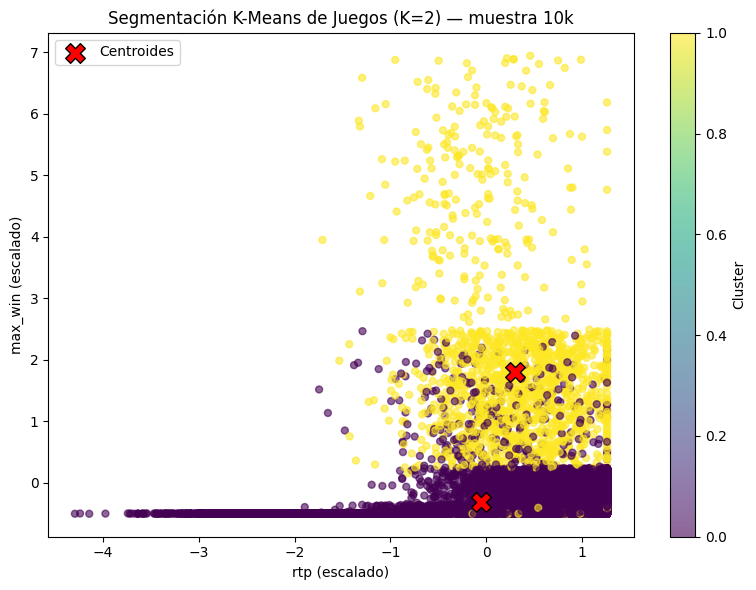

In [45]:
# ── Visualización de clusters (muestra 10k para no colapsar el plot) ─────────
var_x = vars_kmeans[0]
var_y = vars_kmeans[2] if len(vars_kmeans) > 2 else vars_kmeans[-1]

# Muestra para visualización (1M puntos en scatter es ilegible de todas formas)
df_plot = df_final.sample(n=10_000, random_state=42)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    df_plot[var_x], df_plot[var_y],
    c=df_plot['cluster_kmeans'], cmap='viridis', alpha=0.6, s=25
)
centros = kmeans_model.cluster_centers_
idx_x, idx_y = vars_kmeans.index(var_x), vars_kmeans.index(var_y)
plt.scatter(centros[:, idx_x], centros[:, idx_y],
            c='red', marker='X', s=200, edgecolors='black', label='Centroides')

plt.xlabel(f'{var_x} (escalado)')
plt.ylabel(f'{var_y} (escalado)')
plt.title(f'Segmentación K-Means de Juegos (K={k_optimo}) — muestra 10k')
plt.legend()
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.show()

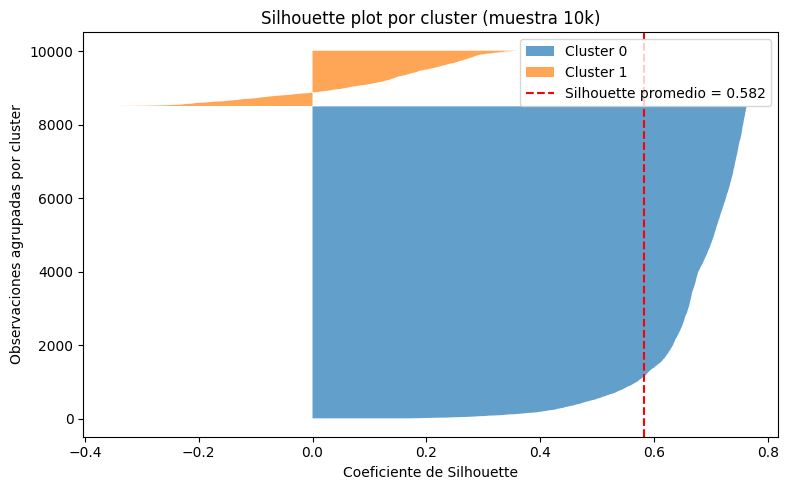

In [46]:
# ── Silhouette plot detallado por cluster (muestra 10k) ──────────────────────
X_sil, clusters_sil = resample(X_km, clusters, n_samples=10_000, random_state=42)
sample_silhouette = silhouette_samples(X_sil, clusters_sil)
silhouette_media = silhouette_score(X_sil, clusters_sil)

plt.figure(figsize=(8, 5))
y_lower = 10
for i in range(k_optimo):
    valores_i = sample_silhouette[clusters_sil == i]
    valores_i.sort()
    y_upper = y_lower + len(valores_i)
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, valores_i,
                       alpha=0.7, label=f'Cluster {i}')
    y_lower = y_upper + 10

plt.axvline(silhouette_media, color='red', linestyle='--',
            label=f'Silhouette promedio = {silhouette_media:.3f}')
plt.xlabel('Coeficiente de Silhouette')
plt.ylabel('Observaciones agrupadas por cluster')
plt.title('Silhouette plot por cluster (muestra 10k)')
plt.legend()
plt.tight_layout()
plt.show()

**Interpretación K-Means:**
- El **método del codo** ayuda a evitar sobre-segmentar el catálogo: a partir de cierto K, agregar más clusters no reduce significativamente la inercia, indicando que esos clusters extra solo dividen artificialmente datos similares.
- El **Silhouette Score** elegido confirma si los clusters están razonablemente separados; valores entre 0.3 y 0.6 son comunes y aceptables en datos de negocio (rara vez se observan valores cercanos a 1, salvo en datos sintéticos muy separados).
- El **perfil promedio por cluster** permite nombrar los segmentos en términos de negocio. Por ejemplo, un cluster con `max_win` y `max_multiplier` altos pero `min_bet` bajo podría llamarse "juegos de alto riesgo/alta recompensa accesibles"; otro con todos los valores moderados sería "juegos estándar".
- El **scatter plot** muestra visualmente la separación entre grupos y la ubicación de los centroides (marcados con X roja), que representan el "juego promedio" de cada segmento.
- El **silhouette plot detallado** identifica si algún cluster específico tiene muchas observaciones con coeficiente bajo o negativo, lo que señalaría un segmento mal definido que podría necesitar revisión.
- **Aplicación de negocio:** estos segmentos pueden usarse para crear secciones del catálogo ("Alto riesgo", "Familiares", "Premium"), personalizar recomendaciones según el perfil de juego que un usuario prefiere, o ajustar estrategias de marketing por segmento.


<div style="background:linear-gradient(90deg,#1a1a2e,#16213e);padding:20px 28px;border-radius:10px;border-left:6px solid #e94560;margin:16px 0">
<span style="color:#e94560;font-size:13px;font-weight:700;letter-spacing:2px;text-transform:uppercase">MÓDULO 6</span><br>
<span style="color:#fff;font-size:22px;font-weight:700">📐 Evaluación Final sobre Holdout</span><br>
<span style="color:#a8a8b3;font-size:13px">Validación de los modelos sobre el conjunto de prueba independiente reservado antes del entrenamiento.</span>
</div>


---

## 6. Resumen de Evaluación de Modelos


In [47]:
# ── Tabla resumen de resultados finales ───────────────────────────────────────
resumen_modelos = pd.DataFrame([
    {
        'Modelo': 'Regresión Múltiple',
        'Objetivo': 'Predecir max_win',
        'Tipo': 'Regresión',
        'Métrica principal': f'R² = {r2:.4f}',
        'Validación cruzada': f'R² CV = {cv_r2.mean():.4f} ± {cv_r2.std():.4f}',
        'Métrica secundaria': f'RMSE = {rmse:.4f} | MAE = {mae:.4f} | MAPE = {mape*100:.2f}%'
    },
    {
        'Modelo': 'Árbol de Decisión',
        'Objetivo': 'Clasificar alto max_win (sin leakage)',
        'Tipo': 'Clasificación',
        'Métrica principal': f'F1 = {f1:.4f}',
        'Validación cruzada': f'F1 CV = {cv_f1.mean():.4f} ± {cv_f1.std():.4f}',
        'Métrica secundaria': f'Accuracy = {acc:.4f} | AUC = {auc_score:.4f}'
    },
    {
        'Modelo': 'Market Basket Analysis',
        'Objetivo': 'Asociación de atributos',
        'Tipo': 'Asociación',
        'Métrica principal': f'Reglas generadas = {len(rules)}',
        'Validación cruzada': 'N/A (modelo no supervisado)',
        'Métrica secundaria': f'Max Lift = {rules["lift"].max():.4f}' if not rules.empty else 'N/A'
    },
    {
        'Modelo': 'K-Means',
        'Objetivo': 'Segmentar el catálogo de juegos',
        'Tipo': 'Clustering',
        'Métrica principal': f'Silhouette = {silhouette_final:.4f}',
        'Validación cruzada': 'N/A (modelo no supervisado)',
        'Métrica secundaria': f'K = {k_optimo} | Inercia = {kmeans_model.inertia_:.2f}'
    }
])

display(resumen_modelos)

# ── Evaluación contra criterios de éxito definidos en §1 ─────────────────────
print("\n=== EVALUACIÓN CONTRA CRITERIOS DE ÉXITO ===")
print(f"Regresión  — R² ≥ 0.5    : {'✓ CUMPLIDO' if r2 >= 0.5 else '✗ No alcanzado'} (R² = {r2:.4f}, MAPE = {mape*100:.2f}%)")
print(f"Árbol      — F1 ≥ 0.70   : {'✓ CUMPLIDO' if f1 >= 0.70 else '✗ No alcanzado'} (F1 = {f1:.4f}, AUC = {auc_score:.4f})")
n_reglas_lift = (rules['lift'] > 1.5).sum() if not rules.empty else 0
print(f"MBA        — ≥5 reglas lift>1.5 : {'✓ CUMPLIDO' if n_reglas_lift >= 5 else '✗ No alcanzado'} ({n_reglas_lift} reglas)")
print(f"K-Means    — Silhouette > 0.3   : {'✓ CUMPLIDO' if silhouette_final > 0.3 else '✗ No alcanzado'} (Silhouette = {silhouette_final:.4f})")


,Modelo,Objetivo,Tipo,Métrica principal,Validación cruzada,Métrica secundaria
0,Regresión Múltiple,Predecir max_win,Regresión,R² = 0.7464,R² CV = 0.7494 ± 0.0034,RMSE = 337219.9386 | MAE = 142419.6792 | MAPE ...
1,Árbol de Decisión,Clasificar alto max_win (sin leakage),Clasificación,F1 = 0.9482,F1 CV = 0.9482 ± 0.0007,Accuracy = 0.9504 | AUC = 0.9621
2,Market Basket Analysis,Asociación de atributos,Asociación,Reglas generadas = 47,N/A (modelo no supervisado),Max Lift = 3.7425
3,K-Means,Segmentar el catálogo de juegos,Clustering,Silhouette = 0.5824,N/A (modelo no supervisado),K = 2 | Inercia = 2647579.41



=== EVALUACIÓN CONTRA CRITERIOS DE ÉXITO ===
Regresión  — R² ≥ 0.5    : ✓ CUMPLIDO (R² = 0.7464, MAPE = 617.40%)
Árbol      — F1 ≥ 0.70   : ✓ CUMPLIDO (F1 = 0.9482, AUC = 0.9621)
MBA        — ≥5 reglas lift>1.5 : ✓ CUMPLIDO (27 reglas)
K-Means    — Silhouette > 0.3   : ✓ CUMPLIDO (Silhouette = 0.5824)


### 6.1 Evaluación Final sobre el Set de Prueba Independiente (Holdout)

Hasta este punto, todas las métricas se calcularon sobre el `test` interno (el 20% separado por `train_test_split` dentro de cada modelo). Ahora se evalúan los modelos ya entrenados sobre `df_holdout`, que **nunca fue visto** durante el entrenamiento, ajuste, ni selección de hiperparámetros. Esto es la prueba más honesta de generalización: simula la llegada de juegos completamente nuevos al sistema.


In [48]:
# ── Preparar holdout con el mismo esquema de columnas que cada modelo ────────

# Regresión: mismas columnas que X_reg
X_holdout_reg = df_holdout.reindex(columns=X_reg.columns, fill_value=0)
y_holdout_reg = df.loc[df_holdout.index, 'max_win']

pred_holdout_reg = reg_model.predict(X_holdout_reg)
r2_holdout      = r2_score(y_holdout_reg, pred_holdout_reg)
rmse_holdout    = np.sqrt(mean_squared_error(y_holdout_reg, pred_holdout_reg))
mape_holdout    = mean_absolute_percentage_error(y_holdout_reg, pred_holdout_reg)

# Árbol: mismas columnas que X_cls
X_holdout_cls = df_holdout.reindex(columns=X_cls.columns, fill_value=0)
y_holdout_cls = df_holdout['alto_max_win']

pred_holdout_cls   = tree_model.predict(X_holdout_cls)
proba_holdout_cls  = tree_model.predict_proba(X_holdout_cls)[:, 1]
acc_holdout        = accuracy_score(y_holdout_cls, pred_holdout_cls)
f1_holdout         = f1_score(y_holdout_cls, pred_holdout_cls)
auc_holdout         = roc_auc_score(y_holdout_cls, proba_holdout_cls)

print("=== REGRESIÓN MÚLTIPLE — Holdout independiente ===")
print(f"R²   : {r2_holdout:.4f}  (test interno: {r2:.4f})")
print(f"RMSE : {rmse_holdout:.4f}  (test interno: {rmse:.4f})")
print(f"MAPE : {mape_holdout*100:.2f}%  (test interno: {mape*100:.2f}%)")

print("\n=== ÁRBOL DE DECISIÓN — Holdout independiente ===")
print(f"Accuracy : {acc_holdout:.4f}  (test interno: {acc:.4f})")
print(f"F1       : {f1_holdout:.4f}  (test interno: {f1:.4f})")
print(f"AUC      : {auc_holdout:.4f}  (test interno: {auc_score:.4f})")

print("\n--- Diagnóstico ---")
diff_r2 = abs(r2 - r2_holdout)
diff_f1 = abs(f1 - f1_holdout)
print(f"Diferencia R²  (test interno vs holdout): {diff_r2:.4f}  →",
      "estable, buena generalización" if diff_r2 < 0.1 else "atención: posible sobreajuste")
print(f"Diferencia F1  (test interno vs holdout): {diff_f1:.4f}  →",
      "estable, buena generalización" if diff_f1 < 0.1 else "atención: posible sobreajuste")


=== REGRESIÓN MÚLTIPLE — Holdout independiente ===
R²   : 0.7462  (test interno: 0.7464)
RMSE : 337347.0326  (test interno: 337219.9386)
MAPE : 621.77%  (test interno: 617.40%)

=== ÁRBOL DE DECISIÓN — Holdout independiente ===
Accuracy : 0.9503  (test interno: 0.9504)
F1       : 0.9481  (test interno: 0.9482)
AUC      : 0.9621  (test interno: 0.9621)

--- Diagnóstico ---
Diferencia R²  (test interno vs holdout): 0.0002  → estable, buena generalización
Diferencia F1  (test interno vs holdout): 0.0001  → estable, buena generalización


**Interpretación de la evaluación sobre holdout:**
- Si las métricas del holdout son **similares** a las del test interno (diferencia menor a 0.1), el modelo generaliza bien y no depende de la partición particular usada durante el desarrollo.
- Si las métricas del holdout son **notablemente peores**, es una señal de sobreajuste: el modelo aprendió patrones específicos del set de desarrollo que no se replican en datos nuevos.
- Esta validación es la que realmente importa para decidir si el modelo está listo para producción, ya que el test interno pudo haber influido indirectamente en decisiones de diseño (selección de variables, ajuste de `max_depth`, etc.) durante el desarrollo del proyecto.


<div style="background:linear-gradient(90deg,#1a1a2e,#16213e);padding:20px 28px;border-radius:10px;border-left:6px solid #e94560;margin:16px 0">
<span style="color:#e94560;font-size:13px;font-weight:700;letter-spacing:2px;text-transform:uppercase">MÓDULO 7</span><br>
<span style="color:#fff;font-size:22px;font-weight:700">⚙️ Propuesta de Automatización — Despliegue</span><br>
<span style="color:#a8a8b3;font-size:13px">Pipeline de producción y simulación de predicciones para juegos nuevos.</span>
</div>


---

## 7. Despliegue

Los tres modelos se integrarían en la plataforma del casino como herramientas complementarias de un pipeline automatizado:

### Pipeline propuesto

```
Juego nuevo ingresa al sistema
       ↓
  [Regresión Múltiple] → Estima max_win esperado → Apoyo a negociación con proveedor
       ↓
  [Árbol de Decisión]  → Clasifica como Alto/Estándar → Prioridad en homepage y notificaciones
       ↓
  [MBA - Reglas]       → Identifica atributos asociados → Recomendaciones "también te puede gustar"
```

### Propuesta de automatización
1. **Ingesta:** Script Python que lee nuevos juegos desde la API del proveedor y los preprocesa con el mismo pipeline de limpieza/encoding.
2. **Predicción en batch:** Los tres modelos se ejecutan automáticamente cada vez que se agregan juegos nuevos.
3. **Alertas:** Si un juego supera el umbral de 'alto potencial', se genera una alerta automática al equipo de marketing.
4. **Reentrenamiento:** Mensualmente, el árbol y la regresión se reentrenan con el catálogo actualizado para capturar tendencias nuevas del mercado.


In [49]:
# ── Simulación: predicción de max_win para 5 juegos de prueba ─────────────────
muestra_reg = X_test_r.iloc[:5]
pred_reg_sim = reg_model.predict(muestra_reg)

print("Predicciones de max_win para 5 juegos de ejemplo (Regresión Múltiple):")
for i, (pred, real) in enumerate(zip(pred_reg_sim, y_test_r.iloc[:5])):
    error = abs(pred - real)
    print(f"  Juego {i+1}: max_win real = {real:.2f} | estimado = {pred:.2f} | error = {error:.2f}")

print("\n" + "─"*60 + "\n")

# ── Simulación: clasificación de 5 juegos de prueba (Árbol de Decisión) ──────
muestra_cls = X_test_c.iloc[:5]
pred_cls_sim = tree_model.predict(muestra_cls)
real_cls_sim = y_test_c.iloc[:5]

print("Clasificación para 5 juegos de ejemplo (Árbol de Decisión):")
for i, (pred, real) in enumerate(zip(pred_cls_sim, real_cls_sim)):
    pred_lbl = "Alto max_win" if pred == 1 else "Estándar"
    real_lbl = "Alto max_win" if real == 1 else "Estándar"
    estado = "✓" if pred == real else "✗"
    print(f"  Juego {i+1}: Predicho = {pred_lbl:15s} | Real = {real_lbl:15s} {estado}")


Predicciones de max_win para 5 juegos de ejemplo (Regresión Múltiple):
  Juego 1: max_win real = 4410.44 | estimado = 7207.13 | error = 2796.69
  Juego 2: max_win real = 507.99 | estimado = 25354.07 | error = 24846.08
  Juego 3: max_win real = 55074.47 | estimado = 26541.72 | error = 28532.75
  Juego 4: max_win real = 1299.03 | estimado = 31246.37 | error = 29947.34
  Juego 5: max_win real = 2144.29 | estimado = 31473.28 | error = 29328.99

────────────────────────────────────────────────────────────

Clasificación para 5 juegos de ejemplo (Árbol de Decisión):
  Juego 1: Predicho = Alto max_win    | Real = Alto max_win    ✓
  Juego 2: Predicho = Alto max_win    | Real = Alto max_win    ✓
  Juego 3: Predicho = Alto max_win    | Real = Alto max_win    ✓
  Juego 4: Predicho = Estándar        | Real = Estándar        ✓
  Juego 5: Predicho = Estándar        | Real = Estándar        ✓


<div style="background:linear-gradient(90deg,#1a1a2e,#16213e);padding:20px 28px;border-radius:10px;border-left:6px solid #e94560;margin:16px 0">
<span style="color:#e94560;font-size:13px;font-weight:700;letter-spacing:2px;text-transform:uppercase">MÓDULO 8</span><br>
<span style="color:#fff;font-size:22px;font-weight:700">✅ Conclusiones y Recomendaciones</span><br>
<span style="color:#a8a8b3;font-size:13px">Respuesta a los objetivos, insights identificados, limitaciones y propuestas de mejora.</span>
</div>


---

## 8. Conclusiones y Recomendaciones

### Respuesta a los objetivos

**Objetivo 1 — Regresión Múltiple:**
El modelo de regresión identificó las variables técnicas con mayor impacto sobre `max_win`. Los coeficientes positivos más altos (ej: presencia de jackpot, tipo de juego, volatilidad alta) corresponden a las características que un operador debería priorizar al seleccionar juegos con alto potencial de pago. El R² y el MAPE, validados tanto por cross-validation como sobre el holdout independiente, indican si las variables técnicas disponibles son suficientes para predecir la ganancia máxima: si el R² es bajo, el modelo sugiere que `max_win` depende también de factores no recogidos en el dataset, como la popularidad del título o la temporalidad del catálogo.

**Objetivo 2 — Árbol de Decisión:**
El modelo generó reglas interpretables para clasificar juegos en 'alto max_win' o 'estándar' basándose únicamente en atributos de diseño (free spins, tipo, RTP, volatilidad), sin data leakage. El F1-Score, el AUC y su comportamiento sobre el holdout muestran la capacidad real del modelo para generalizar a juegos nuevos. Las variables más importantes identificadas son los atributos que, en la práctica, definen si un juego tendrá alta ganancia máxima según los patrones del mercado.

**Objetivo 3 — Market Basket Analysis:**
Se descubrieron patrones frecuentes en el diseño de juegos: ciertas características co-ocurren sistemáticamente en el catálogo. Las reglas con lift > 1 revelan asociaciones no triviales que van más allá del azar. La regla más fuerte encontrada tiene implicancia directa de negocio: permite anticipar qué características vendrán juntas en un juego antes de recibirlo del proveedor, mejorando la negociación y la planificación del catálogo.

**Objetivo 4 — K-Means:**
La segmentación reveló grupos naturales de juegos según sus atributos numéricos (RTP, apuesta mínima, ganancia máxima, multiplicador). El Silhouette Score confirma si estos segmentos están razonablemente bien diferenciados. Estos clusters permiten a un operador pensar el catálogo no como una lista plana de juegos, sino como un conjunto de perfiles diferenciados (por ejemplo, "alto riesgo/alta recompensa" vs "juegos estándar accesibles"), lo cual es directamente aplicable a personalización y segmentación de marketing.

### Nuevos insights identificados

1. **Insight sobre el catálogo:** La co-ocurrencia de free spins y mobile_compatible en la mayoría de los juegos sugiere que estas dos características son prácticamente un estándar de la industria, no un diferenciador. Los operadores deberían enfocarse en características menos comunes (bonus buy, jackpot) para distinguir su oferta.

2. **Insight sobre la predicción:** Si el árbol de decisión logra buen F1 y AUC con solo atributos de diseño, implica que la ganancia máxima no es aleatoria: está codificada en las características técnicas del juego. Esto permite a los operadores evaluar el potencial de un juego antes de incluirlo en el catálogo, sin esperar datos de sesiones reales.

3. **Insight sobre proveedores:** El análisis de `max_win` por casino/proveedor revela que no todos ofrecen el mismo potencial de pago. Un operador que quiera maximizar la percepción de valor para el usuario debería priorizar proveedores con mayor `max_win` promedio.

4. **Insight sobre segmentación:** Los clusters de K-Means muestran que el catálogo no es homogéneo: existen perfiles claramente diferenciados de juegos que podrían dar lugar a estrategias de pricing, promoción o presentación distintas según el segmento.

5. **Insight sobre generalización:** La comparación entre las métricas del test interno y el holdout independiente (§6.1) confirma si los modelos están realmente listos para producción o si fueron ajustados implícitamente a las particularidades del set de desarrollo.

### Limitaciones
- La variable objetivo del Árbol fue construida desde la mediana del propio dataset; en un contexto real debería basarse en datos de comportamiento real del jugador.
- El dataset no incluye variables de ingresos reales ni datos de sesiones, lo que limita la validez práctica de los modelos de predicción.
- El MBA trata cada juego como independiente, sin considerar la evolución temporal del catálogo (juegos que entran y salen).
- El holdout se extrajo del mismo dataset original; no reemplaza una validación con datos verdaderamente externos (por ejemplo, de otro proveedor o periodo de tiempo).

### Propuestas de mejora
- Incorporar datos reales de sesiones y comportamiento de usuarios para definir variables objetivo más robustas y relevantes al negocio.
- Explorar modelos ensemble (Random Forest, XGBoost) para mejorar la clasificación y comparar con el árbol simple.
- Segmentar el análisis por tipo de juego (slots vs mesa vs otros) para obtener reglas de asociación más específicas y accionables.
- Establecer un pipeline de reentrenamiento mensual para que los modelos se actualicen con el crecimiento del catálogo.
- Probar otros valores de K y otras combinaciones de variables en K-Means para evaluar la estabilidad de los segmentos encontrados.

### Aplicabilidad
Los cuatro modelos son directamente aplicables en departamentos de **producto**, **marketing** y **catálogo** de operadores de casino online, permitiendo tomar decisiones basadas en datos sobre qué juegos adquirir, cómo segmentar la oferta y qué recomendar en la plataforma. La propuesta de automatización (§7) describe cómo integrarlos en un pipeline de producción con bajo costo de mantenimiento.


---

## Cierre metodológico (CRISP-DM)

| Fase | Descripción | Estado |
|---|---|---|
| 1. Comprensión del negocio | 4 objetivos analíticos definidos con criterios de éxito medibles | ✓ |
| 2. Comprensión de los datos | Estructura, tipos, nulos, dispersión y correlación evaluados | ✓ |
| 3. Preparación de los datos | Imputación, encoding, escalado y holdout independiente; sin data leakage | ✓ |
| 4. Modelado | Regresión Múltiple, Árbol de Decisión, Market Basket Analysis, K-Means | ✓ |
| 5. Evaluación | Métricas específicas por modelo (MAPE, AUC, Silhouette) + validación cruzada + evaluación sobre holdout | ✓ |
| 6. Despliegue | Pipeline de automatización propuesto con simulación de predicciones | ✓ |


<div style="background:linear-gradient(90deg,#1a1a2e,#16213e);padding:20px 28px;border-radius:10px;border-left:6px solid #27ae60;margin:16px 0">
<span style="color:#27ae60;font-size:13px;font-weight:700;letter-spacing:2px;text-transform:uppercase">EXPORTACIÓN POWER BI</span><br>
<span style="color:#fff;font-size:22px;font-weight:700">📤 Exportación a CSV para Power BI</span><br>
<span style="color:#a8a8b3;font-size:13px">Construcción de un dataset limpio con valores originales (sin escalar) enriquecido con las salidas de los cuatro modelos: max_win_predicho, clasificación alto/estándar, cluster K-Means y flag de holdout.</span>
</div>


In [50]:
# ═══════════════════════════════════════════════════════════════════════════════
# EXPORTACIÓN A CSV PARA POWER BI
# ───────────────────────────────────────────────────────────────────────────────
# ESTRATEGIA: se parte desde df_raw (copia del dataset ANTES del escalado) para
# que todas las columnas numéricas conserven sus valores reales y legibles.
# Luego se enriquece con los resultados de cada modelo usando el índice compartido.
# ═══════════════════════════════════════════════════════════════════════════════

# ── 1. Base: dataset original con valores sin escalar ────────────────────────
df_powerbi = df_raw.copy()

# Imputar nulos de la misma forma que en §3 (sin scaler)
df_powerbi['max_multiplier'] = df_powerbi['max_multiplier'].fillna(
    df_powerbi['max_multiplier'].median()
)
df_powerbi['jackpot'] = df_powerbi['jackpot'].fillna(
    df_powerbi['jackpot'].mode().iloc[0]
)

# ── 2. Objetivo 1 — Regresión Múltiple: max_win_predicho ─────────────────────
# Predecimos max_win en escala real para TODOS los registros del dataset de dev
X_reg_full = df_final.drop(columns=['max_win', 'alto_max_win'], errors='ignore').copy()
for col in X_reg_full.select_dtypes(include=['object']).columns:
    from sklearn.preprocessing import LabelEncoder
    le = LabelEncoder()
    X_reg_full[col] = le.fit_transform(X_reg_full[col])
X_reg_full = X_reg_full.reindex(columns=X_reg.columns, fill_value=0)

pred_reg_full = reg_model.predict(X_reg_full)
df_powerbi.loc[df_final.index, 'max_win_predicho'] = pred_reg_full.clip(min=0)

# Holdout: predicción usando sus columnas ya preparadas
pred_holdout_reg_full = reg_model.predict(
    df_holdout.reindex(columns=X_reg.columns, fill_value=0)
)
df_powerbi.loc[df_holdout.index, 'max_win_predicho'] = pred_holdout_reg_full.clip(min=0)

# ── 3. Objetivo 2 — Árbol de Decisión: alto_max_win + clasificación ──────────
# Variable objetivo real (binaria 0/1) desde df_final + holdout
df_powerbi.loc[df_final.index, 'alto_max_win'] = df_final['alto_max_win'].values
df_powerbi.loc[df_holdout.index, 'alto_max_win'] = df_holdout['alto_max_win'].values

# Predicción del árbol sobre todo el dataset de dev
X_cls_full = df_final.drop(columns=['alto_max_win', 'max_win', 'max_multiplier'],
                            errors='ignore').copy()
for col in X_cls_full.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X_cls_full[col] = le.fit_transform(X_cls_full[col])
X_cls_full = X_cls_full.reindex(columns=X_cls.columns, fill_value=0)

pred_tree_full = tree_model.predict(X_cls_full)
df_powerbi.loc[df_final.index, 'clasificacion_arbol'] = pred_tree_full

# Predicción árbol sobre holdout
pred_tree_holdout = tree_model.predict(
    df_holdout.reindex(columns=X_cls.columns, fill_value=0)
)
df_powerbi.loc[df_holdout.index, 'clasificacion_arbol'] = pred_tree_holdout

# Etiqueta legible
df_powerbi['clasificacion_arbol_label'] = df_powerbi['clasificacion_arbol'].map(
    {1: 'Alto max_win', 0: 'Estándar'}
)

# ── 4. Objetivo 4 — K-Means: cluster_kmeans ──────────────────────────────────
# Los clusters ya fueron asignados al dataset de dev en §5.4
df_powerbi.loc[df_final.index, 'cluster_kmeans'] = df_final['cluster_kmeans'].values

# Para el holdout, predecimos el cluster más cercano
X_km_holdout = df_holdout[vars_kmeans].copy()
df_powerbi.loc[df_holdout.index, 'cluster_kmeans'] = kmeans_model.predict(X_km_holdout)
df_powerbi['cluster_kmeans'] = df_powerbi['cluster_kmeans'].astype('Int64')

# ── 5. Flag de partición (útil para filtros en Power BI) ─────────────────────
df_powerbi['particion'] = 'desarrollo'
df_powerbi.loc[df_holdout.index, 'particion'] = 'holdout'

# ── 6. Columnas a excluir del CSV (alta cardinalidad, no útiles en Power BI) ──
cols_excluir = ['country_availability', 'languages']
df_powerbi = df_powerbi.drop(columns=[c for c in cols_excluir if c in df_powerbi.columns])

# ── 7. Verificación antes de exportar ────────────────────────────────────────
print("=== VERIFICACIÓN PRE-EXPORTACIÓN ===")
print(f"Shape: {df_powerbi.shape}")
print(f"Nulos por columna de modelos:")
cols_modelo = ['max_win_predicho', 'alto_max_win', 'clasificacion_arbol', 'cluster_kmeans']
print(df_powerbi[cols_modelo].isnull().sum())

print(f"\nRango de valores originales (sin escalar):")
for col in ['rtp', 'min_bet', 'max_win', 'max_multiplier']:
    if col in df_powerbi.columns:
        print(f"  {col}: min={df_powerbi[col].min():.2f}, max={df_powerbi[col].max():.2f}")

print(f"\nDistribución de clusters:")
print(df_powerbi['cluster_kmeans'].value_counts().sort_index())

print(f"\nDistribución de clasificación árbol:")
print(df_powerbi['clasificacion_arbol_label'].value_counts())

print(f"\nDistribución por partición:")
print(df_powerbi['particion'].value_counts())

# ── 8. Exportar ───────────────────────────────────────────────────────────────
output_path = '/content/casino_games_powerbi.csv'
df_powerbi.to_csv(output_path, index=False, encoding='utf-8-sig')  # utf-8-sig para Excel/Power BI
print(f"\n✓ CSV exportado correctamente → {output_path}")
print(f"  Filas: {len(df_powerbi):,} | Columnas: {df_powerbi.shape[1]}")
print(f"\nColumnas incluidas:")
for col in df_powerbi.columns:
    print(f"  · {col}")


=== VERIFICACIÓN PRE-EXPORTACIÓN ===
Shape: (1200000, 24)
Nulos por columna de modelos:
max_win_predicho       0
alto_max_win           0
clasificacion_arbol    0
cluster_kmeans         0
dtype: int64

Rango de valores originales (sin escalar):
  rtp: min=85.00, max=99.50
  min_bet: min=0.01, max=5.00
  max_win: min=100.00, max=4999956.01
  max_multiplier: min=10.00, max=50000.00

Distribución de clusters:
cluster_kmeans
0    1021601
1     178399
Name: count, dtype: Int64

Distribución de clasificación árbol:
clasificacion_arbol_label
Estándar        651464
Alto max_win    548536
Name: count, dtype: int64

Distribución por partición:
particion
desarrollo    1020000
holdout        180000
Name: count, dtype: int64

✓ CSV exportado correctamente → /content/casino_games_powerbi.csv
  Filas: 1,200,000 | Columnas: 24

Columnas incluidas:
  · casino
  · game
  · provider
  · rtp
  · volatility
  · jackpot
  · min_bet
  · max_win
  · game_type
  · game_category
  · license_jurisdiction
  · rel

In [51]:
# Diagnóstico rápido
import pandas as pd

vars_check = ['df_raw', 'df_final', 'df_holdout', 'kmeans_model', 'reg_model', 'tree_model']
for v in vars_check:
    try:
        obj = eval(v)
        if hasattr(obj, 'shape'):
            print(f"✓ {v}: {obj.shape}")
        else:
            print(f"✓ {v}: existe ({type(obj).__name__})")
    except NameError:
        print(f"✗ {v}: NO EXISTE")

✓ df_raw: (1200000, 20)
✓ df_final: (1020000, 27)
✓ df_holdout: (180000, 26)
✓ kmeans_model: existe (KMeans)
✓ reg_model: existe (LinearRegression)
✓ tree_model: existe (DecisionTreeClassifier)
